<a href="https://colab.research.google.com/github/mehrerm/TFM/blob/main/notebooks/EDA_ML_densidadRT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



En esta aplicación implementaremos un modelo de puntuación de riesgo poblacional a la mortalidad debido a los cánceres más comunes y su relación con las cantidades y tecnologías usadas en radioterapia por país.

In [128]:
#Cargo o importo pandas, numpy, Matplotlib,
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf # Importar ols desde aquí





import requests
import unicodedata
import os
from pathlib import Path

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, mean_squared_error

!pip install optbinning
from optbinning import OptimalBinning, Scorecard, BinningProcess
from sklearn.linear_model import LogisticRegression, LinearRegression
from urllib.parse import quote




#lugar donde se van guardando las figuras

output_path = Path("TFM/data/processed")
output_path.mkdir(parents=True, exist_ok=True)

fig_dir = "figuras"
os.makedirs(fig_dir, exist_ok=True)

#########################

Carga de datos ya depurados

In [133]:
url = 'https://raw.githubusercontent.com/mehrerm/TFM/refs/heads/main/data/processed/'
#df_merged = pd.read_csv(url + "df_merged_WHO.csv")
#df_merged = pd.read_csv(url + "df_merged_WHO_diag.csv")

df_merged = pd.read_csv("df_merged_WHO_diag.csv")
display(df_merged.head())

,Year,Population,Population_male,Population_female,ISO3,Population id,Cancer label,Sex,Type,ASR (World),...,Total,Region Name,Year_Units,RT_m,GDP_per_capita,TAC,GammaC,MRI,Mammography,PET
0,2015,1292275.0,648341.0,643934.0,MUS,480,Lung,Male,Mortality,14.084766,...,109,Africa,2010,2.31,9630.543784,6.16,2.31,4.62,57.98,0.0
1,2015,1292275.0,648341.0,643934.0,MUS,480,Lung,Female,Mortality,5.710436,...,55,Africa,2010,2.31,9630.543784,6.16,2.31,4.62,57.98,0.0
2,2015,1292275.0,648341.0,643934.0,MUS,480,Breast,Female,Mortality,19.737396,...,177,Africa,2010,2.31,9630.543784,6.16,2.31,4.62,57.98,0.0
3,2015,1292275.0,648341.0,643934.0,MUS,480,Prostate,Male,Mortality,8.993800,...,65,Africa,2010,2.31,9630.543784,6.16,2.31,4.62,57.98,0.0
4,2015,1292275.0,648341.0,643934.0,MUS,480,Cervix,Female,Mortality,3.731733,...,33,Africa,2010,2.31,9630.543784,6.16,2.31,4.62,57.98,0.0


In [134]:
df_merged.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1085 entries, 0 to 1084
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year               1085 non-null   int64  
 1   Population         1085 non-null   float64
 2   Population_male    1085 non-null   float64
 3   Population_female  1085 non-null   float64
 4   ISO3               1085 non-null   object 
 5   Population id      1085 non-null   int64  
 6   Cancer label       1085 non-null   object 
 7   Sex                1085 non-null   object 
 8   Type               1085 non-null   object 
 9   ASR (World)        1085 non-null   float64
 10  Crude rate         1085 non-null   float64
 11  Cumulative risk    1085 non-null   float64
 12  Total              1085 non-null   int64  
 13  Region Name        1085 non-null   object 
 14  Year_Units         1085 non-null   int64  
 15  RT_m               1085 non-null   float64
 16  GDP_per_capita     1085 

Los datos se encuentran limpios y fucionados en un solo dataframe. Ahora se realiza una exploración previa.

Antes de abordar los análisis de relación, se realizó un análisis exploratorio visual estratificado por año y sexo, con el objetivo de contextualizar la evolución temporal de la incidencia y la mortalidad por cáncer. Este análisis permitió identificar el periodo más adecuado para el estudio principal, teniendo en cuenta posibles distorsiones en los indicadores de salud asociadas a acontecimientos excepcionales, como la pandemia de COVID-19 en el 2020, que alteró significativamente los patrones de diagnóstico y tratamiento. Con esto además, podemos visualizar como evoluciona la incidencia y mortalidad en el tiempo, si existen diferencias sistemáticas por sexo y detectar patrones globales.


Primeramente borramos algunas columnas que no nos interesa, como por ejemplo. Indicator, Crude rate	Cumulative y risk	Total.



In [138]:
df_merged = df_merged.drop(columns=['Crude rate', 'Cumulative risk', "Year_Units", 'Total'])

KeyError: "['Crude rate', 'Cumulative risk', 'Year_Units', 'Total'] not found in axis"

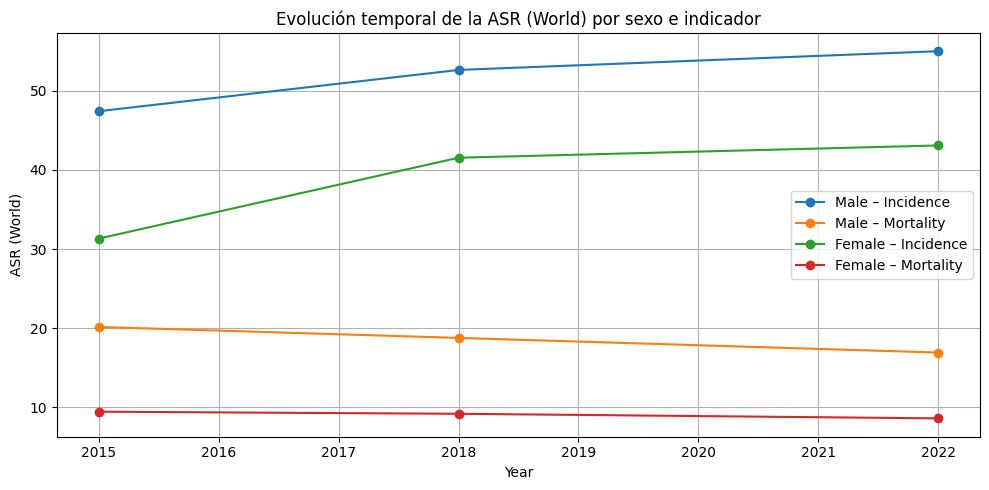

In [153]:
df_trend = (
    df_merged
    .dropna(subset=["Year", "ASR (World)", "Sex", "Type"])
    .groupby(["Year", "Sex", "Type"], as_index=False)
    .agg({"ASR (World)": "mean"})
    .sort_values("Year")
)

%matplotlib inline

plt.figure(figsize=(10,5))

for sex in ["Male", "Female"]:
    for t in ["Incidence", "Mortality"]:
        sub = df_trend[(df_trend["Sex"] == sex) & (df_trend["Type"] == t)]
        plt.plot(
            sub["Year"],
            sub["ASR (World)"],
            marker="o",
            label=f"{sex} – {t}"
        )

plt.xlabel("Year")
plt.ylabel("ASR (World)")
plt.title("Evolución temporal de la ASR (World) por sexo e indicador")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{fig_dir}/fig01_figure_ASR_anno.jpg", dpi=300, bbox_inches="tight")
plt.show()


#Se grafica entonces la evolución temporal de la ASR, estratificado por sexo

En a serie temporal no parece evidenciar o estar afecto por el COVID19, los datos del 2018 y 2022 son bastante parecidos, esto también nos podría suponer que no ha evolucionado significativamente la tasa de mortalidad, lo que si queda claro, es que los hombres y mujeres tienen incidencias y mortalidad distintas, con casi los mismo comportamientos pero de magnitud diferente.
En nuestro estudio existen solamente tres años porque son los años que se tiene registro de la cantidad de equipos de radioterapia y su evolución a lo largo de esos tres años registrados, como ya se mencionó en la depuración, se consideró sumarle 5 años a los registros  de los equipos ya que es ese tiempo aproximadamente en el que se puede saber si efectivamente los equipos de radioterapia (A partir de ahora, RT) han surtido efecto en la mortalidad.





Se busca entonces ver como se comporta la mortalidad e incidencia por año.

In [155]:
idx = (
    df_merged
    .groupby(["ISO3", "Sex", "Type"])["Year"]
    .idxmax()
)

df_latest = df_merged.loc[idx].reset_index(drop=True)


<Figure size 1000x500 with 0 Axes>

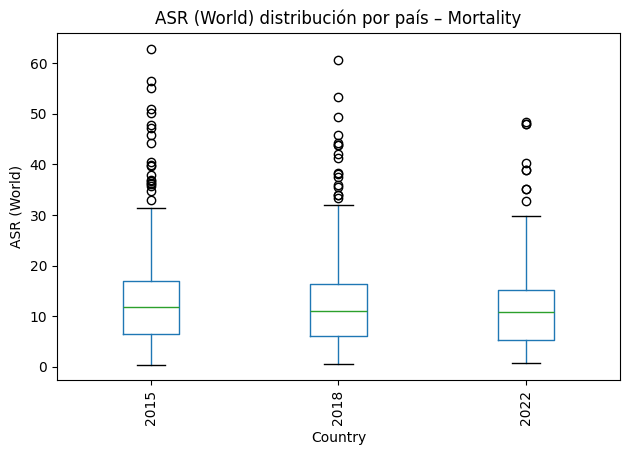

<Figure size 1000x500 with 0 Axes>

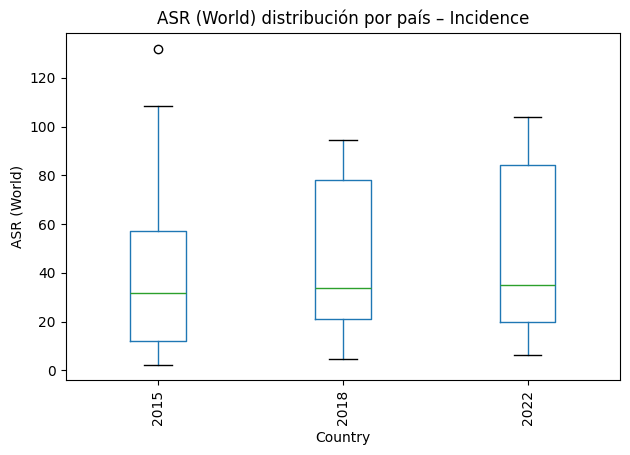

                count       mean        std       min        25%        50%  \
Type      Year                                                                
Incidence 2015  210.0  37.760526  29.306871  2.279390  11.796643  31.704972   
          2018   20.0  45.966859  32.841461  4.611827  21.016206  33.647772   
          2022   30.0  47.842069  34.262574  6.242416  19.646427  34.806863   
Mortality 2015  300.0  13.748971  10.739895  0.388140   6.419846  11.762913   
          2018  280.0  13.035889  10.141584  0.541023   6.052555  11.010309   
          2022  245.0  11.950008   8.931221  0.668701   5.359303  10.791069   

                      75%         max  
Type      Year                         
Incidence 2015  57.320187  132.046692  
          2018  77.994580   94.690075  
          2022  84.118158  103.896318  
Mortality 2015  17.032979   62.917421  
          2018  16.400917   60.588763  
          2022  15.227584   48.374439  


In [156]:
df_plot = df_merged.copy()


for t in df_plot["Type"].unique():
    plt.figure(figsize=(10,5))

    df_plot[df_plot["Type"] == t].boxplot(
        column="ASR (World)",
        by="Year",
        grid=False,
        rot=90
    )

    plt.title(f"ASR (World) distribución por país – {t}")
    plt.suptitle("")
    plt.xlabel("Country")
    plt.ylabel("ASR (World)")
    plt.tight_layout()
    plt.savefig(f"{fig_dir}/fig02_boxplot_ASR_{t}.jpg", dpi=300, bbox_inches="tight")
    plt.show()

stats_simple = (
    df_plot
    .groupby(["Type", "Year"])["ASR (World)"]
    .describe()
)

print(stats_simple)



Estas figuras muestran la distribución de las tasas de incidencia y mortalidad estandarizadas por edad (ASR World) para los años 2015-2018-2022 mediante diagramas de caja y bigotes. En ambos casos se observa una elevada heterogeneidad entre países, reflejada en amplios rangos intercuartílicos y la presencia sistemática de valores atípicos. Por el contrario, la mortalidad muestra una distribución con outliers muchos outliers, lo que sugiere una mayor dependencia de la capacidad terapéutica de los sistemas sanitarios.

Para determinar si se puede utilizar ambas variables,
Para continuar con el análisis estadístico y valorar que año y paises utilizar en nuestro trabajo, se busca entonces valorar que paises tienen los datos de incidencia y/o mortalidad.


Es importante resaltar desde el principio de que nuestra variable objetivo es la tasa de mortalidad  ASR (World) y ver que relación tiene con los equipos de radioaterapia, incidencia, PIB per capita, sexo, región, etc.



In [160]:
#cuantos paises hay con año, tipo de cancer y tipo

counts = (
    df_merged
    .groupby(
        ["ISO3", "Year", "Cancer label", "Type"]
    )
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

 # cuantos países tienen los datos completos (both) o incompletos?

counts["both"] = (
    (counts.get("Incidence", 0) > 0) &
    (counts.get("Mortality", 0) > 0)
)

counts["only_incidence"] = (
    (counts.get("Incidence", 0) > 0) &
    (counts.get("Mortality", 0) == 0)
)

counts["only_mortality"] = (
    (counts.get("Incidence", 0) == 0) &
    (counts.get("Mortality", 0) > 0)
)

summary = {
    "Total combinaciones país–año–cáncer": len(counts),
    "Con incidencia y mortalidad": counts["both"].sum(),
    "Solo incidencia": counts["only_incidence"].sum(),
    "Solo mortalidad": counts["only_mortality"].sum(),
}
print(
    f"Total combinaciones país–año–cáncer: {summary['Total combinaciones país–año–cáncer']}\n"
    f"Con incidencia y mortalidad: {summary['Con incidencia y mortalidad']}\n"
    f"Solo incidencia: {summary['Solo incidencia']}\n"
    f"Solo mortalidad: {summary['Solo mortalidad']}"
)


#Un resumen por año

by_year = (
    counts
    .groupby("Year")[["both", "only_incidence", "only_mortality"]]
    .sum()
)

print(by_year)

#resumen por pais

by_country = (
    counts
    .groupby("ISO3")[["both", "only_incidence", "only_mortality"]]
    .sum()
    .sort_values("both")
)





Total combinaciones país–año–cáncer: 648
Con incidencia y mortalidad: 152
Solo incidencia: 48
Solo mortalidad: 448
Type  both  only_incidence  only_mortality
Year                                      
2015   136              32             104
2018     8               8             216
2022     8               8             128


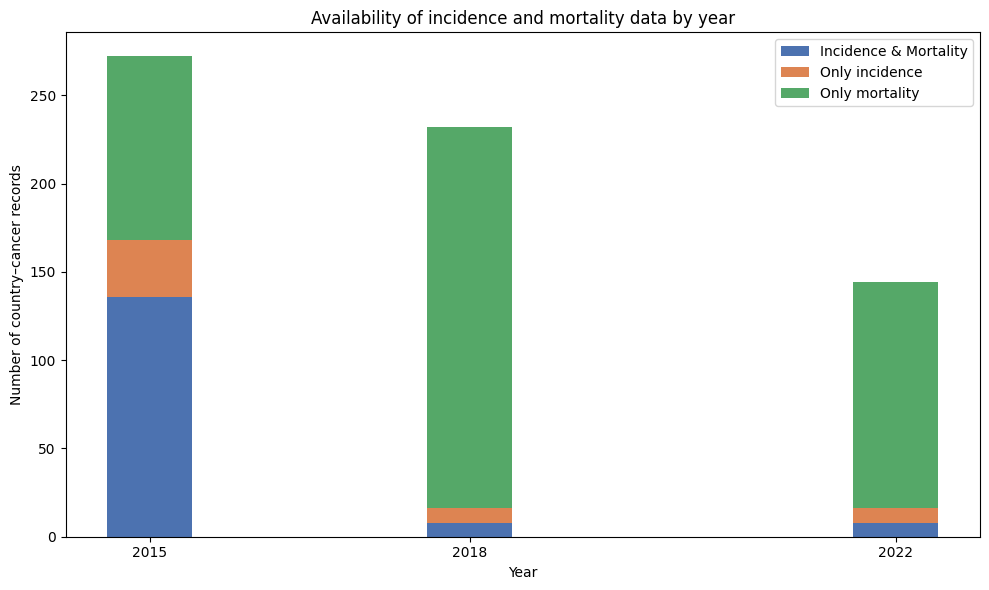

In [161]:
plt.figure(figsize=(10, 6))

plt.bar(
    by_year.index,
    by_year["both"],
    label="Incidence & Mortality",
    color="#4C72B0"
)

plt.bar(
    by_year.index,
    by_year["only_incidence"],
    bottom=by_year["both"],
    label="Only incidence",
    color="#DD8452"
)

plt.bar(
    by_year.index,
    by_year["only_mortality"],
    bottom=by_year["both"] + by_year["only_incidence"],
    label="Only mortality",
    color="#55A868"
)

plt.xlabel("Year")
plt.ylabel("Number of country–cancer records")
plt.title("Availability of incidence and mortality data by year")
plt.legend()
plt.tight_layout()
plt.xticks(by_year.index.astype(int))


plt.show()


Se observó una reducción generalizada en el número de países con datos de incidencia disponibles a partir de 2018 para todos los tipos de cáncer analizados. Este cambio de cobertura limita la comparabilidad temporal de las medias anuales posteriores a dicho año, por lo que los análisis longitudinales se interpretan con cautela y se prioriza el uso de mortalidad como variable objetivo.

In [162]:

df_merged_all = df_merged.copy()


# Quedarse solo con mortalidad
df_merged_all = df_merged_all[df_merged_all["Type"] == "Mortality"].copy()



# Ver qué años hay y cuántas observaciones por año
df_merged_all["Year"].value_counts().sort_index()


,count
Year,
2015,300
2018,280
2022,245


Con estos datos, ahora si, se procede a evaluar con gráficos y estadísitcas que se tiene por cada tipo de cancer.

In [163]:
df_merged_all["Cancer label"].unique()

array(['Lung', 'Breast', 'Prostate', 'Cervix'], dtype=object)

Con la finalidad de entender si existe algún patrón de comportamiento de estos tipos de cancer con variables como PIB y RT, se procede a utilizar graficos de dispersión.

In [164]:
#Se renombran las columnas
df_model = df_merged_all.rename(columns={
    "Cancer label": "Cancer",
    "Region Name": "Region",
   #"Country_harmonized": "Country",
    "ASR (World)" : "ASR",
    "GDP_per_capita" : "GDP",
    "RT_m" : "RT"
})




In [165]:
df_model.head()

,Year,Population,Population_male,Population_female,ISO3,Population id,Cancer,Sex,Type,ASR,Region,RT,GDP,TAC,GammaC,MRI,Mammography,PET
0,2015,1292275.0,648341.0,643934.0,MUS,480,Lung,Male,Mortality,14.084766,Africa,2.31,9630.543784,6.16,2.31,4.62,57.98,0.0
1,2015,1292275.0,648341.0,643934.0,MUS,480,Lung,Female,Mortality,5.710436,Africa,2.31,9630.543784,6.16,2.31,4.62,57.98,0.0
2,2015,1292275.0,648341.0,643934.0,MUS,480,Breast,Female,Mortality,19.737396,Africa,2.31,9630.543784,6.16,2.31,4.62,57.98,0.0
3,2015,1292275.0,648341.0,643934.0,MUS,480,Prostate,Male,Mortality,8.993800,Africa,2.31,9630.543784,6.16,2.31,4.62,57.98,0.0
4,2015,1292275.0,648341.0,643934.0,MUS,480,Cervix,Female,Mortality,3.731733,Africa,2.31,9630.543784,6.16,2.31,4.62,57.98,0.0


Se grafica las dispersiones.

In [166]:
df_model['log_GDP'] = np.log(df_model['GDP'])

In [168]:
def plot_all_cancers(df, x, y):
    fig = px.scatter(
        df,
        x=x,
        y=y,
        color="Cancer",
        facet_col="Sex",
        facet_row="Year",
        hover_name="ISO3",
        title=f"Grafica de dispersion entre {x} y {y} por tipo de cáncer, año y sexo"
    )
    fig.update_layout(height=800, width=1000)
    plt.savefig(f"{fig_dir}/scatter {x} vs {y} para {"Sex"}.jpg", dpi=300, bbox_inches="tight")
    fig.show()



plot_all_cancers(df_model, "log_GDP", "ASR")

plot_all_cancers(df_model, "RT", "ASR")

<Figure size 640x480 with 0 Axes>

Se observa una tendencia general a que, a mayor PIB per cápita (log_GDP), menor es la Tasa de Mortalidad Estandarizada por Edad (ASR) pero con cierto umbral, donde, un menor per capita supone menor mortalidad, pero a medida que crece hasta cierto punto, baja, esto posiblemente se debe al tabaquismo, contaminación u otro factor no lineal. Esto sugiere que el desarrollo económico hasta cierto punto puede ayudar, asi conjuntamente el sistema sanitario, ambos juegan un papel crucial en la reducción de la mortalidad por cáncer. Sin embargo, esta relación no es perfectamente lineal y varía entre cánceres. Por ejemplo, algunos cánceres pueden mostrar una disminución más pronunciada que otros a medida que aumenta el PIB.

ASR vs. Radioterapia (RT): La relación entre la disponibilidad de equipos de radioterapia y la mortalidad es más compleja y específica de cada cáncer.


Cáncer de Cérvix: Visualmente, es probable que se observe que un aumento en la disponibilidad de RT se correlaciona con una disminución en la ASR, especialmente en rangos bajos de RT, lo que podría ser debido a un efecto umbral. Los puntos de datos para este cáncer se concentran en la parte inferior izquierda de los gráficos cuando hay poca RT y se desplazan aún mas hacia abajo y a la derecha a medida que aumenta la RT.
Cáncer de Mama y Próstata: Para estos cánceres, la relación con la RT parece menos consistente o más dispersa. Los puntos de datos pueden estar más agrupados o mostrar una correlación más débil.

Diferencias por Sexo y Año: Los gráficos revelan que las tendencias pueden variar entre hombres y mujeres para el mismo tipo de cáncer, y también a lo largo de los años, usando el cancer de pulmon para este fin.


Con el objetivo de identificar las variables que podrían influir en la tasa de mortalidad, se realiza un análisis mediante una matriz de correlaciones, diferenciando por sexo, dado que los patrones de incidencia y mortalidad presentan comportamientos significativamente distintos entre hombres y mujeres.


In [169]:
df_model_f = df_model[df_model["Sex"] == "Female"].copy()
df_model_f.drop(columns=["Population_male", "Type", "Sex"], inplace=True)


In [170]:
df_model_f.info()

<class 'pandas.core.frame.DataFrame'>
Index: 495 entries, 1 to 1084
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year               495 non-null    int64  
 1   Population         495 non-null    float64
 2   Population_female  495 non-null    float64
 3   ISO3               495 non-null    object 
 4   Population id      495 non-null    int64  
 5   Cancer             495 non-null    object 
 6   ASR                495 non-null    float64
 7   Region             495 non-null    object 
 8   RT                 495 non-null    float64
 9   GDP                495 non-null    float64
 10  TAC                495 non-null    float64
 11  GammaC             495 non-null    float64
 12  MRI                495 non-null    float64
 13  Mammography        495 non-null    float64
 14  PET                495 non-null    float64
 15  log_GDP            495 non-null    float64
dtypes: float64(11), int64(2), obje

In [171]:
df_model_m = df_model[df_model["Sex"] == "Male"].copy()
df_model_m.drop(columns=["Population_female", "Type", "Sex"], inplace=True)
df_model_m.head()


,Year,Population,Population_male,ISO3,Population id,Cancer,ASR,Region,RT,GDP,TAC,GammaC,MRI,Mammography,PET,log_GDP
0,2015,1292275.0,648341.0,MUS,480,Lung,14.084766,Africa,2.31,9630.543784,6.16,2.31,4.62,57.98,0.0,9.172695
3,2015,1292275.0,648341.0,MUS,480,Prostate,8.993800,Africa,2.31,9630.543784,6.16,2.31,4.62,57.98,0.0,9.172695
5,2018,1288833.0,646826.0,MUS,480,Lung,10.543072,Africa,2.41,11818.748062,6.43,2.41,4.82,0.00,0.0,9.377442
8,2018,1288833.0,646826.0,MUS,480,Prostate,12.165378,Africa,2.41,11818.748062,6.43,2.41,4.82,0.00,0.0,9.377442
10,2022,1276130.0,638999.0,MUS,480,Lung,10.937588,Africa,3.14,10246.501746,0.00,0.00,0.00,0.00,0.0,9.234692


In [172]:
df_model_m.info()

<class 'pandas.core.frame.DataFrame'>
Index: 330 entries, 0 to 1083
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             330 non-null    int64  
 1   Population       330 non-null    float64
 2   Population_male  330 non-null    float64
 3   ISO3             330 non-null    object 
 4   Population id    330 non-null    int64  
 5   Cancer           330 non-null    object 
 6   ASR              330 non-null    float64
 7   Region           330 non-null    object 
 8   RT               330 non-null    float64
 9   GDP              330 non-null    float64
 10  TAC              330 non-null    float64
 11  GammaC           330 non-null    float64
 12  MRI              330 non-null    float64
 13  Mammography      330 non-null    float64
 14  PET              330 non-null    float64
 15  log_GDP          330 non-null    float64
dtypes: float64(11), int64(2), object(3)
memory usage: 43.8+ KB


Ahora, se buscan las variables que nos interesa

In [192]:
df = df_model_m.copy()


cols_corr_m = [
    "ASR", "RT", "Population_male", "log_GDP", "TAC",	"GammaC",	"MRI",
  	"PET"
]

In [193]:


corr_m = df[cols_corr_m].corr()
corr_m

,ASR,RT,Population_male,log_GDP,TAC,GammaC,MRI,PET
ASR,1.000000,0.017513,-0.106466,-0.018381,0.041681,0.055178,0.023260,-0.003079
RT,0.017513,1.000000,0.279691,0.755825,0.190185,0.281378,0.246119,0.370242
Population_male,-0.106466,0.279691,1.000000,0.121111,0.095805,0.138861,0.166912,0.101677
log_GDP,-0.018381,0.755825,0.121111,1.000000,0.255385,0.320403,0.322885,0.366198
TAC,0.041681,0.190185,0.095805,0.255385,1.000000,0.453706,0.875834,0.732088
GammaC,0.055178,0.281378,0.138861,0.320403,0.453706,1.000000,0.515837,0.621010
MRI,0.023260,0.246119,0.166912,0.322885,0.875834,0.515837,1.000000,0.684376
PET,-0.003079,0.370242,0.101677,0.366198,0.732088,0.621010,0.684376,1.000000


Lo que se puede ver es que la señal es bastante débil si juntamos las variables, ahora bien, debido a que cada tipo de cancer tiene su protocolo y no son comparables, se estratifica por tipo de cancer.

In [194]:
def plot_corr_heatmap(df, cols_corr, cancer):
  df_ = df[df["Cancer"] == cancer]

  corr_ = df_[cols_corr].corr()

  plt.figure(figsize=(8, 6))
  sns.heatmap(
    corr_,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0
  )
  plt.title("Correlation heatmap – " f"{cancer}")
  plt.tight_layout()
  plt.show()
  plt.savefig(f"{fig_dir}/heatmap_corr_{cancer} para {"Sex"}.jpg", dpi=300, bbox_inches="tight")


  return corr_, df_

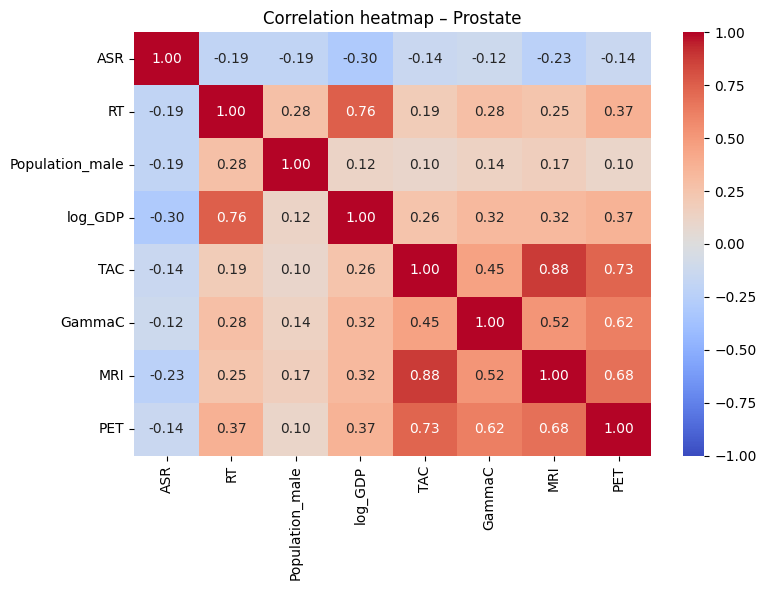

<Figure size 640x480 with 0 Axes>

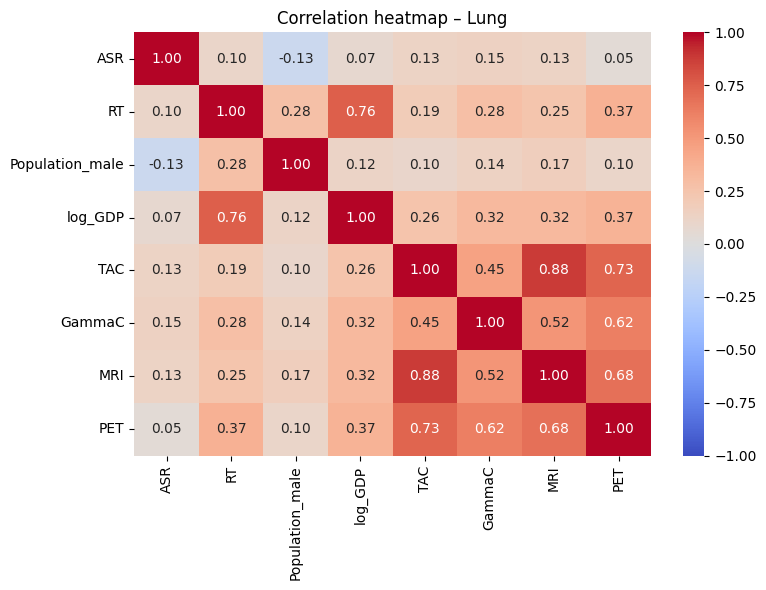

<Figure size 640x480 with 0 Axes>

In [195]:
corr_prostate, df_prostate = plot_corr_heatmap(df_model_m, cols_corr_m, "Prostate")

corr_lung_m, df_lung_m = plot_corr_heatmap(df_model_m, cols_corr_m, "Lung")


En estos mapas de calor podemos ver una muy fuerte correlación entre el pib per capita y los equipos RT, pero

In [196]:
df = df_model_f.copy()


cols_corr_f = [
    "ASR", "RT", "Population_female", "log_GDP", "TAC",	"GammaC",	"MRI",
    "Mammography",	"PET"
]

corr = df[cols_corr_f].corr()
corr

,ASR,RT,Population_female,log_GDP,TAC,GammaC,MRI,Mammography,PET
ASR,1.000000,0.072251,-0.010725,0.031906,-0.034285,0.073524,-0.047965,-0.010872,0.018647
RT,0.072251,1.000000,0.275557,0.755825,0.190185,0.281378,0.246119,0.123655,0.370242
Population_female,-0.010725,0.275557,1.000000,0.117930,0.099280,0.133071,0.169448,0.108882,0.101088
log_GDP,0.031906,0.755825,0.117930,1.000000,0.255385,0.320403,0.322885,0.155965,0.366198
TAC,-0.034285,0.190185,0.099280,0.255385,1.000000,0.453706,0.875834,0.493833,0.732088
GammaC,0.073524,0.281378,0.133071,0.320403,0.453706,1.000000,0.515837,0.496773,0.621010
MRI,-0.047965,0.246119,0.169448,0.322885,0.875834,0.515837,1.000000,0.559846,0.684376
Mammography,-0.010872,0.123655,0.108882,0.155965,0.493833,0.496773,0.559846,1.000000,0.468633
PET,0.018647,0.370242,0.101088,0.366198,0.732088,0.621010,0.684376,0.468633,1.000000


El mapa de calor revela patrones heterogéneos en la relación entre densidad de radioterapia y mortalidad según el tipo de cáncer. En particular, el cáncer de cérvix muestra una reducción abrupta de la mortalidad al superar niveles medios de dotación de radioterapia, evidenciando un claro efecto umbral. En contraste, otros cánceres como pulmón presentan patrones inversos, probablemente asociados a diferencias en detección y registro más que a un efecto causal directo de la radioterapia. Estos resultados refuerzan la necesidad de enfoques diferenciados en la planificación de infraestructuras de radioterapia, priorizando aquellos cánceres donde el impacto potencial es mayor.

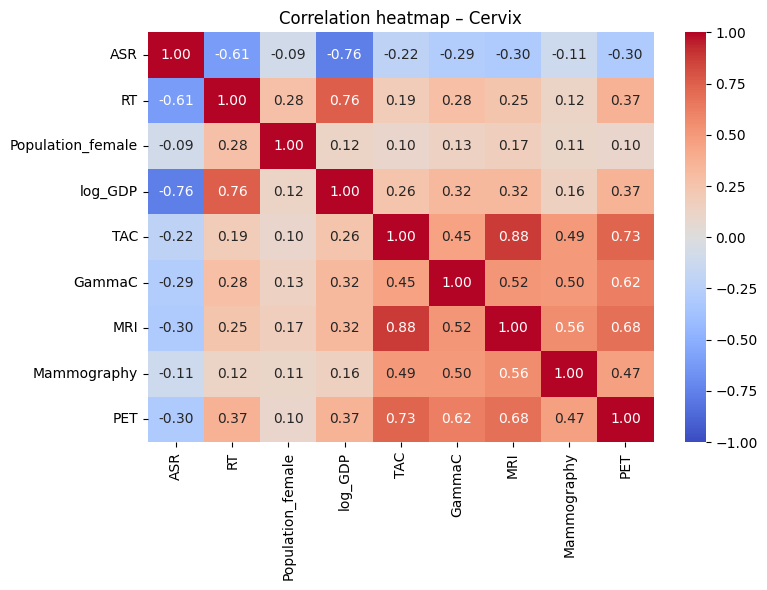

<Figure size 640x480 with 0 Axes>

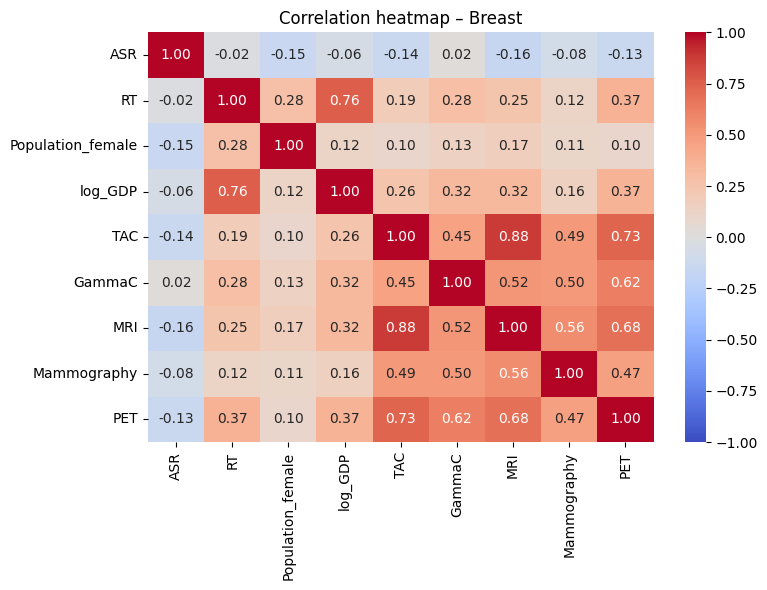

<Figure size 640x480 with 0 Axes>

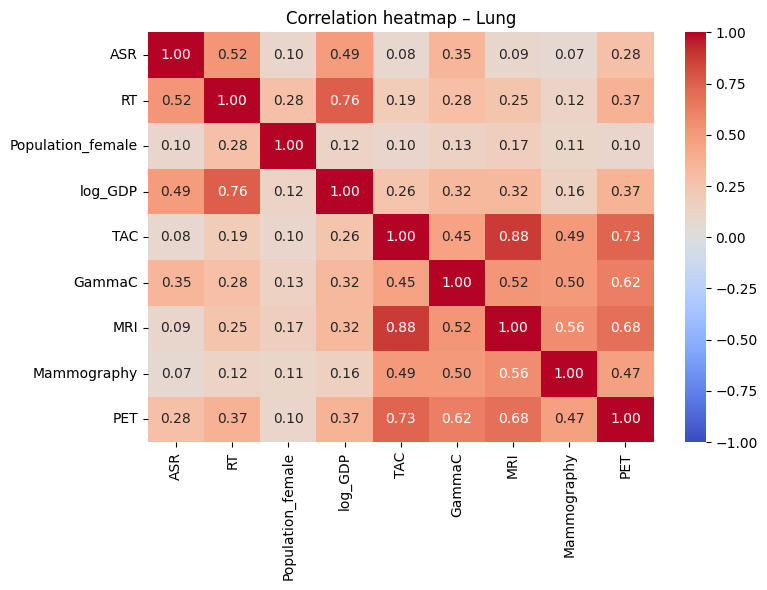

<Figure size 640x480 with 0 Axes>

In [197]:
corr_cervix, df_cervix = plot_corr_heatmap(df_model_f, cols_corr_f, "Cervix")

corr_breast, df_breast = plot_corr_heatmap(df_model_f, cols_corr_f, "Breast")

corr_lung_f, df_lung_f = plot_corr_heatmap(df_model_f, cols_corr_f, "Lung")

Analizando los mapas de colores, encontramos que paradojicamente existen tipos de cáncer que aumentan con la cantidad de equipos y PIB per capita, este es el caso de pulmón en ambos sexos, sin embargo, se puede ver claramente que tanto para cervix como prostata, tratamientos muy bien protocolizados en tratamientos con radioterapia externa, si tienen un gran impacto, el valor negativo nos indica que disminuye a media que aumenta el número de la variable predictora.

Entonces, nos centraremos en estos dos tipo de canceres.



Ahora, se busca si por regiones, estos dos tipo de canceres cambia.

A partir de aquí y debido a que tenemos solamente dos variables predictoras, utilizaremos métodos adecuados a lo que tenemos disponible.

¿Existe un umbral de numero de RT donde se puede optimizar sus bondades y aún así optener buenos resultados epidemiológicos tanto en próstata con en cervix?
O ¿Entre más equipos existe menos mortalidad?

Empezando con un modelo base sencillo: regresión lineal.

### Regresión lineal para hombres (ASR ~ log_GDP + RT)

In [198]:
df_cervix.describe()

,Year,Population,Population_female,Population id,ASR,RT,GDP,TAC,GammaC,MRI,Mammography,PET,log_GDP
count,165.000000,1.650000e+02,1.650000e+02,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000
mean,2018.096970,3.089068e+07,1.561041e+07,406.406061,3.667999,4.536242,29072.858533,9.064909,3.091091,4.821030,41.443758,0.605230,9.870272
std,2.839667,5.935653e+07,2.973329e+07,237.368703,2.708875,3.416306,24669.242946,15.218031,5.889276,8.011149,87.535563,1.303738,0.988413
min,2015.000000,3.563330e+05,1.771300e+05,32.000000,0.388140,0.000000,1283.520304,0.000000,0.000000,0.000000,0.000000,0.000000,7.157362
25%,2015.000000,4.323387e+06,2.086352e+06,208.000000,1.446800,1.470000,10024.819111,0.000000,0.000000,0.000000,0.000000,0.000000,9.212819
50%,2018.000000,9.064677e+06,4.574595e+06,380.000000,3.074132,3.960000,20221.103686,2.910000,0.000000,0.800000,0.000000,0.000000,9.914482
75%,2022.000000,3.729500e+07,1.878008e+07,608.000000,5.101708,6.780000,41929.754911,13.250000,3.700000,8.140000,40.840000,0.570000,10.643751
max,2022.000000,3.415340e+08,1.698613e+08,862.000000,13.175513,13.160000,116926.759594,101.700000,48.370000,46.160000,521.600000,8.290000,11.669303


In [203]:
model_prostate_ols = smf.ols(
    "ASR ~ log_GDP + RT + TAC + GammaC + MRI + Mammography + PET", # Añadida la coma aquí
    data=df_prostate
).fit()

print(model_prostate_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                    ASR   R-squared:                       0.133
Model:                            OLS   Adj. R-squared:                  0.095
Method:                 Least Squares   F-statistic:                     3.449
Date:                Fri, 13 Feb 2026   Prob (F-statistic):            0.00184
Time:                        21:38:43   Log-Likelihood:                -480.63
No. Observations:                 165   AIC:                             977.3
Df Residuals:                     157   BIC:                             1002.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      25.8640      5.056      5.116      

### Evaluación de RMSE y Validación Cruzada para Cáncer de Próstata

In [204]:
# --- RMSE para el modelo OLS de Próstata ya ajustado ---
X_prostate = df_prostate[["log_GDP", "RT"]]
y_pred_prostate = model_prostate_ols.predict(X_prostate)
rmse_prostate = np.sqrt(mean_squared_error(df_prostate["ASR"], y_pred_prostate))
print(f"RMSE (Modelo OLS Próstata): {rmse_prostate:.3f}")

# --- Validación Cruzada para Próstata ---

y_prostate = df_prostate["ASR"]

lr_prostate = LinearRegression()
cv_prostate = KFold(n_splits=5, shuffle=True, random_state=42)

r2_scores_prostate = cross_val_score(
    lr_prostate, X_prostate, y_prostate,
    cv=cv_prostate,
    scoring="r2"
)

rmse_scores_prostate = -cross_val_score(
    lr_prostate, X_prostate, y_prostate,
    cv=cv_prostate,
    scoring="neg_root_mean_squared_error"
)

print(f"CV R² (Próstata): {r2_scores_prostate.mean():.3f} ± {r2_scores_prostate.std():.3f}")
print(f"CV RMSE (Próstata): {rmse_scores_prostate.mean():.3f} ± {rmse_scores_prostate.std():.3f}")

PatsyError: predict requires that you use a DataFrame when predicting from a model
that was created using the formula api.

The original error message returned by patsy is:
Error evaluating factor: NameError: name 'TAC' is not defined
    ASR ~ log_GDP + RT + TAC + GammaC + MRI + Mammography + PET
                         ^^^

En las métricas se puede observar que tanto el GDP como RT explican muy poca de la variabilidad de la mortalidad documentada, tan solo un 8%. Otro punto a considerar es que el coeficiente, además de ser casi nulo para RT, es positivo, algo que no tiene mucho sentido, viendo los diagramas de dispersión se puede ver que son puntos dispersos.

### Regresión lineal para mujeres (ASR ~ log_GDP + RT)

In [223]:
model_cervix_ols = smf.ols(
    "ASR ~ log_GDP + RT + TAC +\tGammaC +\tMRI + PET", # Añadida la coma aquí
    data=df_cervix
).fit()

print(model_cervix_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                    ASR   R-squared:                       0.584
Model:                            OLS   Adj. R-squared:                  0.568
Method:                 Least Squares   F-statistic:                     37.00
Date:                Fri, 13 Feb 2026   Prob (F-statistic):           8.81e-28
Time:                        22:15:16   Log-Likelihood:                -325.66
No. Observations:                 165   AIC:                             665.3
Df Residuals:                     158   BIC:                             687.1
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     22.1784      1.966     11.283      0.0

Con resultados donde se predice el 58% de la variabilidad, se puede decir que el PIB per capita es el dominante y el intervalo está lejos de cero. Esto es coherente con que la infraestructura sanitaria está correlacionada con desarrollo economico.

Sin embargo, el resto de variables podrían presentar outliers que podrían distorsionar el modelo.

In [230]:
residuals = model_cervix_ols.resid_pearson
outliers = df_cervix[np.abs(residuals) > 3]

outliers


,Year,Population,Population_female,ISO3,Population id,Cancer,ASR,Region,RT,GDP,TAC,GammaC,MRI,Mammography,PET,log_GDP
24,2015,56723537.0,29194266.0,ZAF,710,Cervix,12.971971,Africa,0.60,6112.273825,1.02,0.56,0.24,9.11,0.060,8.718054
29,2018,58613001.0,30211846.0,ZAF,710,Cervix,13.175513,Africa,0.57,6914.178032,0.97,0.53,0.23,0.00,0.057,8.841329
969,2018,791556.0,403661.0,GUY,328,Cervix,11.997842,Americas,1.25,6048.386972,3.75,0.00,1.25,0.00,0.000,8.707547


In [233]:
df_cervix_clean = df_cervix.drop(outliers.index).copy()

In [239]:
model_cervix_ols = smf.ols(
    "ASR ~ log_GDP + RT", # Añadida la coma aquí
    data=df_cervix_clean
).fit()

print(model_cervix_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                    ASR   R-squared:                       0.614
Model:                            OLS   Adj. R-squared:                  0.609
Method:                 Least Squares   F-statistic:                     126.6
Date:                Fri, 13 Feb 2026   Prob (F-statistic):           1.29e-33
Time:                        22:44:05   Log-Likelihood:                -296.20
No. Observations:                 162   AIC:                             598.4
Df Residuals:                     159   BIC:                             607.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     21.6347      1.647     13.135      0.0

📊 ANÁLISIS DE LOS RESULTADOS DEL MODELO OLSBasándome en los resultados que compartiste, aquí está mi evaluación del modelo de regresión para la mortalidad por cáncer cervical (ASR):✅ ASPECTOS POSITIVOS:1. Bondad de Ajuste:R-squared: 0.584 - El modelo explica el 58.4% de la variabilidad en la mortalidad por cáncer cervical, lo cual es razonablemente bueno.Adj. R-squared: 0.568 - Muy cercano al R², indicando que las variables incluidas son apropiadas.2. Significancia Global:F-statistic: 37.00 con Prob (F-statistic): 8.81e-28 - El modelo en su conjunto es altamente significativo.3. Variables Significativas:log_GDP: coef = -1.8328, p = 0.000 (altamente significativo)

Por cada unidad de aumento en log_GDP, la mortalidad disminuye en 1.83 unidades. Esto tiene sentido: mayor desarrollo económico se asocia con menor mortalidad.

RT (Radioterapia): coef = -0.0709, p = 0.268 (no significativo, pero negativo como se esperaría)

⚠️ PROBLEMAS IDENTIFICADOS:1. Variables NO Significativas:TAC: p = 0.491GammaC: p = 0.618MRI: p = 0.208PET: p = 0.669Ninguna de estas tecnologías de diagnóstico muestra significancia estadística. Esto podría indicar:Multicolinealidad entre estas variablesQue su disponibilidad no impacta directamente en la mortalidadQue el efecto está mediado por otras variables (como el GDP)2. Durbin-Watson: 0.817Este valor sugiere autocorrelación positiva en los residuos (lo ideal sería cercano a 2). Esto puede indicar que hay patrones en los datos que el modelo no está capturando.3. Jarque-Bera: 115.649 con Prob(JB): 7.71e-26Los residuos NO siguen una distribución normal, lo cual viola uno de los supuestos de la regresión OLS. Esto puede afectar la validez de las inferencias estadísticas.4. Kurtosis: 6.229Indica que los residuos tienen colas más pesadas de lo normal, sugiriendo la presencia de outliers.

### Evaluación de RMSE y Validación Cruzada para Cáncer de Cérvix

In [209]:
# --- RMSE para el modelo OLS de Cérvix ya ajustado ---
y_pred_cervix = model_cervix_ols.predict(df_cervix)
rmse_cervix = np.sqrt(mean_squared_error(df_cervix["ASR"], y_pred_cervix))
print(f"RMSE (Modelo OLS Cérvix): {rmse_cervix:.3f}")

# --- Validación Cruzada para Cérvix ---
X_cervix = df_cervix[["log_GDP", "RT"]]
y_cervix = df_cervix["ASR"]

lr_cervix = LinearRegression()
cv_cervix = KFold(n_splits=5, shuffle=True, random_state=42)

r2_scores_cervix = cross_val_score(
    lr_cervix, X_cervix, y_cervix,
    cv=cv_cervix,
    scoring="r2"
)

rmse_scores_cervix = -cross_val_score(
    lr_cervix, X_cervix, y_cervix,
    cv=cv_cervix,
    scoring="neg_root_mean_squared_error"
)

print(f"CV R² (Cérvix): {r2_scores_cervix.mean():.3f} ± {r2_scores_cervix.std():.3f}")
print(f"CV RMSE (Cérvix): {rmse_scores_cervix.mean():.3f} ± {rmse_scores_cervix.std():.3f}")

RMSE (Modelo OLS Cérvix): 1.741
CV R² (Cérvix): 0.556 ± 0.081
CV RMSE (Cérvix): 1.756 ± 0.228


Antes de continuar, se procede a verificar Multicolinealidad VIF

In [226]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Definir X con las variables predictoras usadas en el modelo OLS de cervix
X = df_cervix[["log_GDP", "RT", "TAC", "GammaC", "MRI", "Mammography", "PET"]]

# Crear un DataFrame para almacenar los resultados del VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print(vif_data.sort_values(by="VIF", ascending=False))

      Variable       VIF
2          TAC  7.243864
4          MRI  6.803086
1           RT  3.999015
0      log_GDP  3.912592
6          PET  3.687026
3       GammaC  2.378869
5  Mammography  1.963970


Aunque el coeficiente de determinación obtenido en validación cruzada es relativamente elevado para este tipo de datos agregados, los resultados se interpretan con cautela, dado que pueden reflejar estructuras latentes no completamente capturadas por el modelo, como diferencias regionales.

en el caso de Cervix, estas dos variables explican el 58%  de la variabilidad de la tasa de mortalidad en Cervix, usando OLS. A pesar de tener un coeficiente bastante pequeño para RT.

En este caso, R2 es bastante robusto y útil para entender el fenómeno, según este método, el 58% de la variabilidad de ASR es explicada con estas dos variables, pib per capita y RT, también es cierto que RT tiene un valor bastante bajo, sin embargo, posiblemente si estudiamos con otros modelos su comportamiento, podríamos encontrar algo más interesante.

Antes de continuar, se dejará aquí plasmado los resultados de OLS del resto de tipo de cancer estudiados, con el fin de saber su comportamiento a pesar de no encontrar significancia usando la matriz de correlación.


Para mama

In [211]:
model_breast_ols = smf.ols(
    "ASR ~ log_GDP + RT + TAC +\tGammaC +\tMRI + PET + Mammography",
    data=df_breast
).fit()

print(model_breast_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                    ASR   R-squared:                       0.053
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     1.255
Date:                Fri, 13 Feb 2026   Prob (F-statistic):              0.276
Time:                        21:44:08   Log-Likelihood:                -430.13
No. Observations:                 165   AIC:                             876.3
Df Residuals:                     157   BIC:                             901.1
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      15.3256      3.723      4.117      

##Para pulmon en mujeres

In [214]:
model_lung_f_ols = smf.ols(
    "ASR ~ log_GDP + RT + TAC +\tGammaC +\tMRI + PET",
    data=df_lung_f
).fit()

print(model_lung_f_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                    ASR   R-squared:                       0.363
Model:                            OLS   Adj. R-squared:                  0.339
Method:                 Least Squares   F-statistic:                     14.99
Date:                Fri, 13 Feb 2026   Prob (F-statistic):           1.54e-13
Time:                        21:58:21   Log-Likelihood:                -484.36
No. Observations:                 165   AIC:                             982.7
Df Residuals:                     158   BIC:                             1004.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -4.6444      5.143     -0.903      0.3

In [213]:
model_lung_m_ols = smf.ols(
    "ASR ~ log_GDP + RT + TAC +\tGammaC +\tMRI + PET",
    data=df_lung_m
).fit()

print(model_lung_m_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                    ASR   R-squared:                       0.056
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     1.563
Date:                Fri, 13 Feb 2026   Prob (F-statistic):              0.161
Time:                        21:45:13   Log-Likelihood:                -653.51
No. Observations:                 165   AIC:                             1321.
Df Residuals:                     158   BIC:                             1343.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     29.1743     14.336      2.035      0.0

Al incluir simultáneamente múltiples indicadores de infraestructura tecnológica, el modelo muestra una pérdida sustancial de capacidad explicativa y significación global, lo que sugiere la presencia de colinealidad y estructura no modelada. Este resultado refuerza la necesidad de enfoques parsimoniosos y regularizados para este tipo de datos.

Siguiendo la linea de buscar el mejor modelo, procedemos con alguno basado en arboles, pero bastante limitado ya que la muestra es limitada.

Primeramente haremos un modelo con la variable más significativa que es el PIB per capita.


COMPARACIÓN DE MODELOS
           Modelo  R² (CV)
Gradient Boosting 0.614909
    Random Forest 0.614509
          OLS pib 0.554713
            Lasso 0.553424
      Elastic Net 0.552134
            Ridge 0.551173


/tmp/ipython-input-834400879.py:85: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




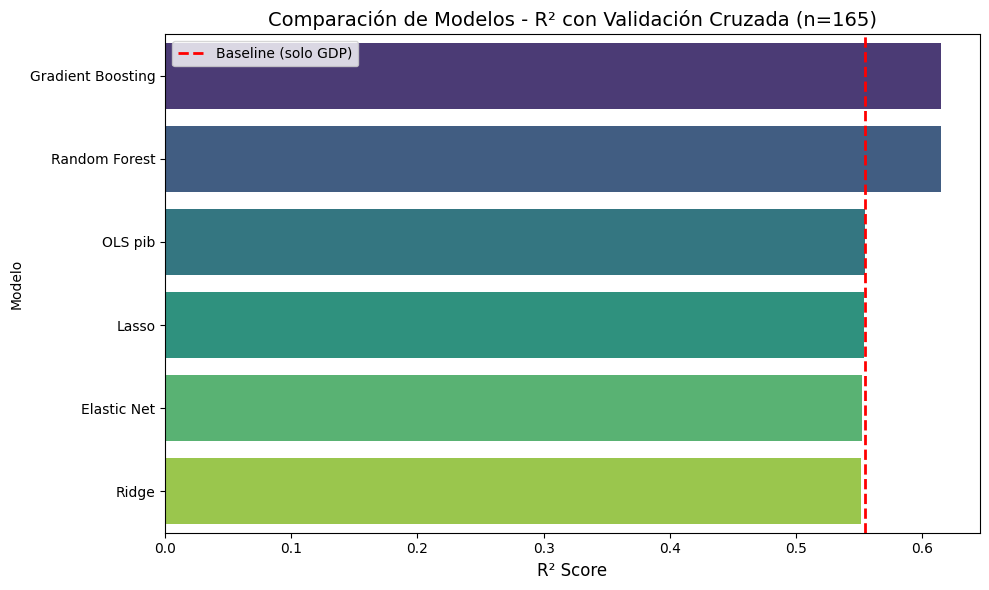

In [244]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, KFold
import pandas as pd
import numpy as np
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV, LinearRegression
from sklearn.preprocessing import StandardScaler


rf = RandomForestRegressor(
    n_estimators=50,
    max_depth=3,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

y = df_cervix["ASR"]
X = df_cervix[["log_GDP"]]
X_baseline = df_cervix[['log_GDP']]

# Escalar datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Configurar validación cruzada
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Diccionario para almacenar resultados
resultados = {}

# 1. OLS baseline (solo log_GDP)
ols_baseline = LinearRegression()
scores_ols = cross_val_score(ols_baseline, X_baseline, y, cv=cv, scoring='r2')
resultados['OLS pib'] = scores_ols.mean()

# 2. Ridge
X_scaled_ridge = scaler.fit_transform(X) # Re-escalar para cada modelo si X es modificado
ridge = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5)
scores_ridge = cross_val_score(ridge, X_scaled_ridge, y, cv=cv, scoring='r2')
resultados['Ridge'] = scores_ridge.mean()

# 3. Lasso
X_scaled_lasso = scaler.fit_transform(X) # Re-escalar para cada modelo
lasso = LassoCV(alphas=np.logspace(-3, 3, 50), cv=5, max_iter=10000)
scores_lasso = cross_val_score(lasso, X_scaled_lasso, y, cv=cv, scoring='r2')
resultados['Lasso'] = scores_lasso.mean()

# 4. Elastic Net
X_scaled_elastic = scaler.fit_transform(X) # Re-escalar para cada modelo
elastic = ElasticNetCV(alphas=np.logspace(-3, 3, 30), l1_ratio=[0.3, 0.5, 0.7], cv=5, max_iter=10000)
scores_elastic = cross_val_score(elastic, X_scaled_elastic, y, cv=cv, scoring='r2')
resultados['Elastic Net'] = scores_elastic.mean()

# 5. Random Forest (limitado)

rf_model = RandomForestRegressor(n_estimators=50, max_depth=3, min_samples_split=10,
                           min_samples_leaf=5, random_state=42)
scores_rf = cross_val_score(rf_model, X, y, cv=cv, scoring='r2')
resultados['Random Forest'] = scores_rf.mean()

# 6. Gradient Boosting (conservador)
# X no necesita escalado para GradientBoostingRegressor
gb_model = GradientBoostingRegressor(n_estimators=50, learning_rate=0.05, max_depth=2,
                               min_samples_split=10, min_samples_leaf=5, random_state=42)
scores_gb = cross_val_score(gb_model, X, y, cv=cv, scoring='r2')
resultados['Gradient Boosting'] = scores_gb.mean()

# Crear dataframe de resultados
df_resultados = pd.DataFrame({
    'Modelo': list(resultados.keys()),
    'R² (CV)': list(resultados.values())
}).sort_values('R² (CV)', ascending=False)

print("\n" + "="*50)
print("COMPARACIÓN DE MODELOS")
print("="*50)
print(df_resultados.to_string(index=False))
print("="*50)

# Visualizar

plt.figure(figsize=(10, 6))
sns.barplot(data=df_resultados, y='Modelo', x='R² (CV)', palette='viridis')
plt.title('Comparación de Modelos - R² con Validación Cruzada (n=' + str(len(df_cervix)) + ')', fontsize=14)
plt.xlabel('R² Score', fontsize=12)
plt.axvline(x=resultados['OLS pib'], color='red', linestyle='--',
            label='Baseline (solo GDP)', linewidth=2)
plt.legend()
plt.tight_layout()
plt.show()

Dado el tamaño muestral limitado, los modelos basados en árboles se restringieron a un número reducido de variables y a profundidades muy bajas, con el objetivo de evitar sobreajuste y preservar la interpretabilidad.

Siguiendo los resultados de nuestro modelo base, parece que Gradient Boosting es el que mejor se adapta, mejorando un 6% del modelo OLS.
Ahora, analizando la importancia de las caracteristicas, se tiene:

IMPORTANCIA DE CARACTERÍSTICAS - GRADIENT BOOSTING
  Variable  Importancia
0  log_GDP     0.806530
1       RT     0.107528
2      TAC     0.040492
5   GammaC     0.025664
3      MRI     0.018289
4      PET     0.001496



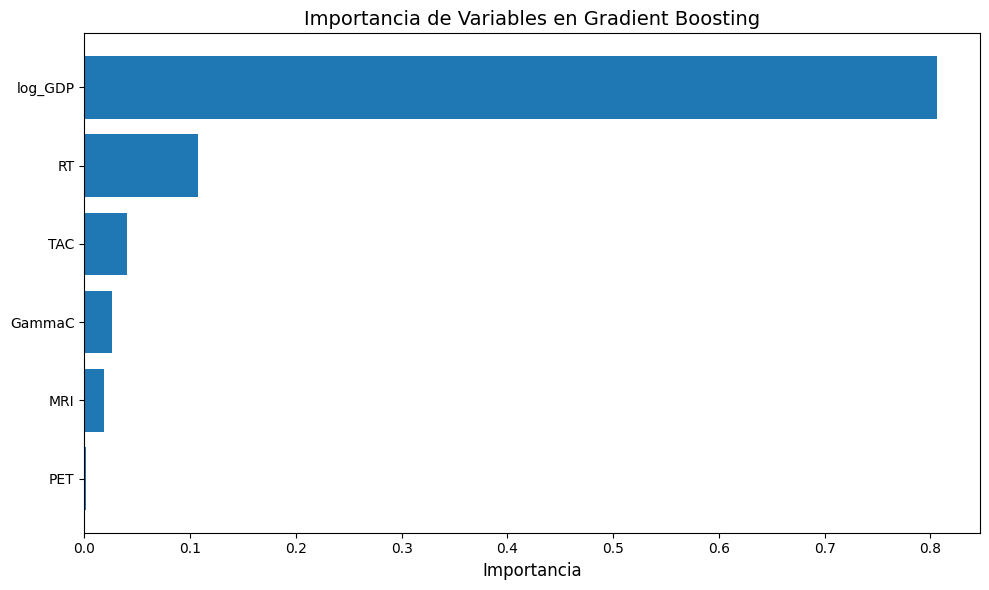

In [254]:
# Entrenar Gradient Boosting
from sklearn.ensemble import GradientBoostingRegressor
import pandas as pd
import matplotlib.pyplot as plt

gb = GradientBoostingRegressor(
    n_estimators=50,
    learning_rate=0.05,
    max_depth=2,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

y = df_cervix["ASR"]
X = df_cervix[["log_GDP", "RT", "TAC", "MRI", "PET", "GammaC"]]

gb.fit(X, y)

# Importancia de características
feature_importance = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': gb.feature_importances_
}).sort_values('Importancia', ascending=False)

print("="*50)
print("IMPORTANCIA DE CARACTERÍSTICAS - GRADIENT BOOSTING")
print("="*50)
print(feature_importance)
print()

# Visualizar
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Variable'], feature_importance['Importancia'])
plt.xlabel('Importancia', fontsize=12)
plt.title('Importancia de Variables en Gradient Boosting', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

PIB domina completamente, es por mucho, el factor mas importante. El resto tiene importancia marginal.


Debido al limitado tamaño muestral, nos quedaremos con los más importantes que son el PIB y RT. Y vuelvo a ejecutar la celda anterior con estas dos variables solamente.





IMPORTANCIA DE CARACTERÍSTICAS - GRADIENT BOOSTING
  Variable  Importancia
0  log_GDP     0.863798
1       RT     0.136202



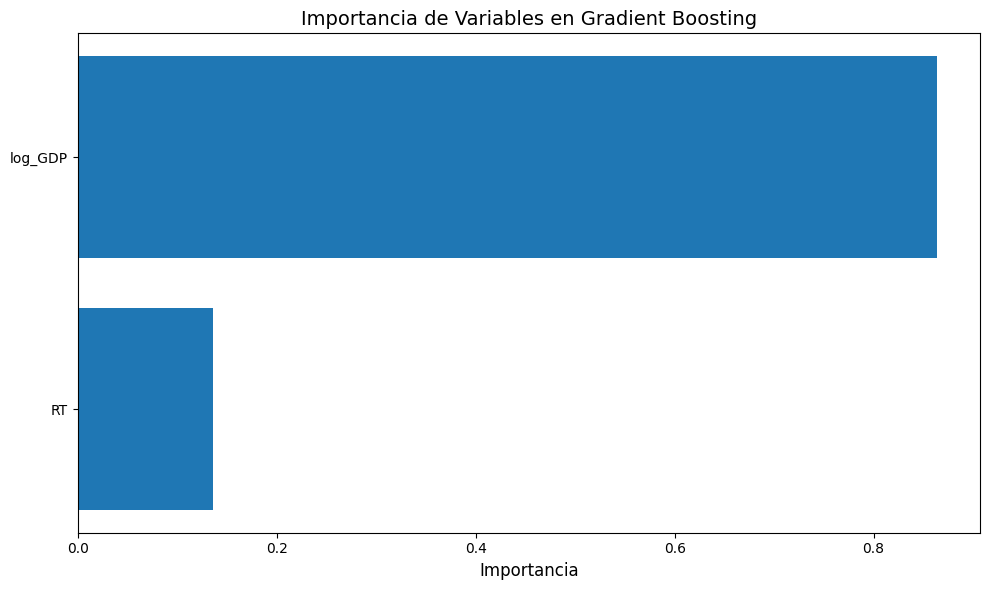

In [255]:
X = df_cervix[["log_GDP", "RT"]]

gb.fit(X, y)

# Importancia de características
feature_importance = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': gb.feature_importances_
}).sort_values('Importancia', ascending=False)

print("="*50)
print("IMPORTANCIA DE CARACTERÍSTICAS - GRADIENT BOOSTING")
print("="*50)
print(feature_importance)
print()

# Visualizar
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Variable'], feature_importance['Importancia'])
plt.xlabel('Importancia', fontsize=12)
plt.title('Importancia de Variables en Gradient Boosting', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

La importancia del 13%, es la segunda variable más importante.

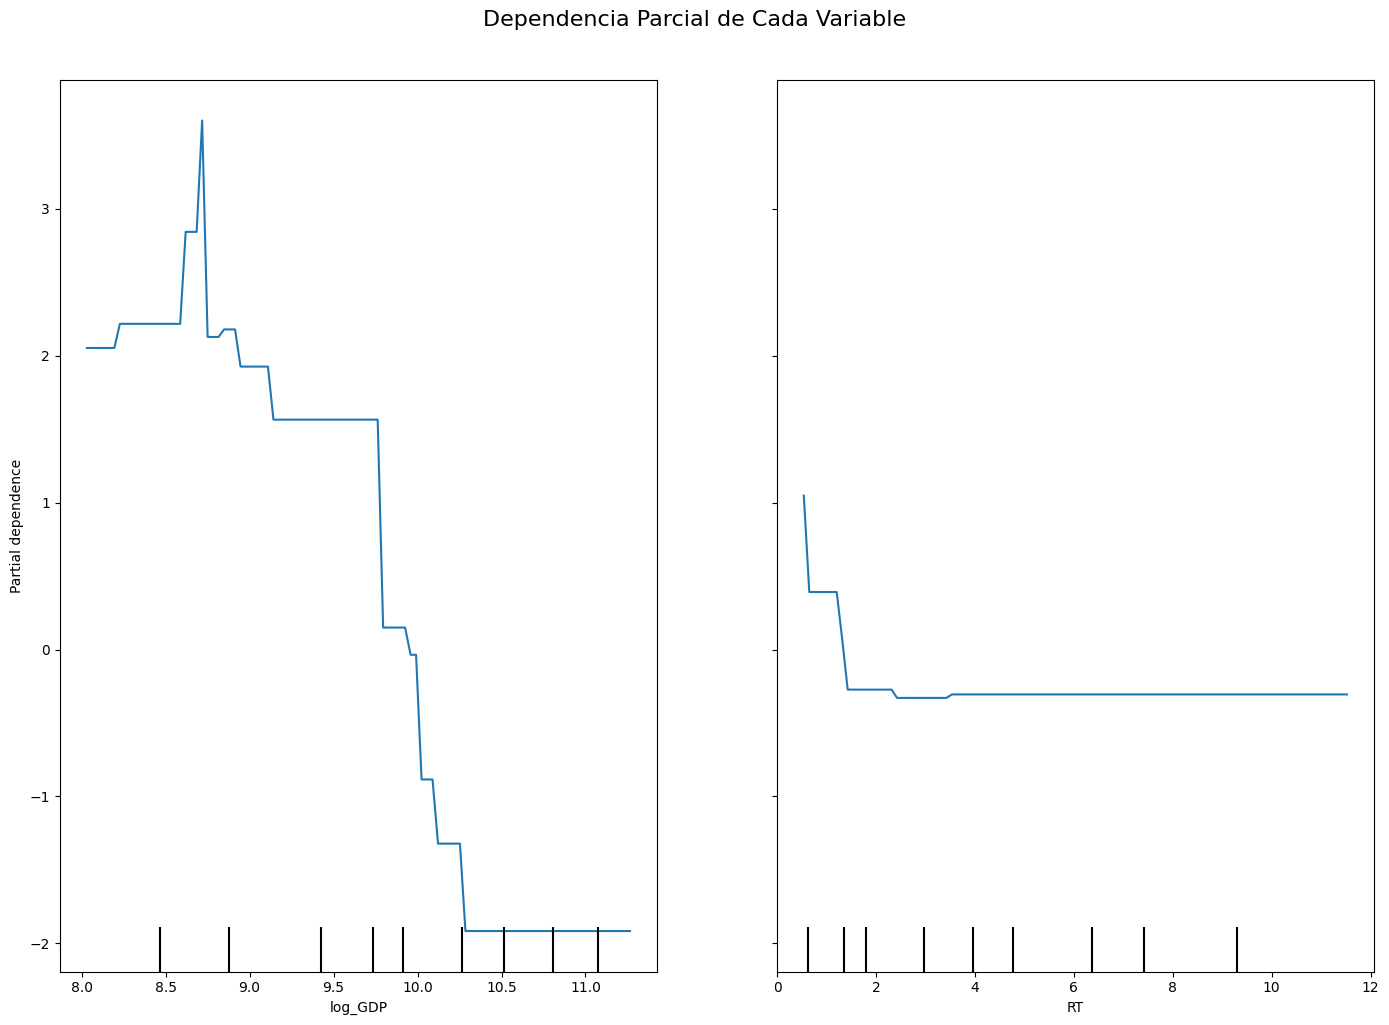

In [256]:
from sklearn.inspection import PartialDependenceDisplay

# Ver cómo cada variable afecta la predicción
fig, ax = plt.subplots(figsize=(14, 10))
features_to_plot = list(range(len(X.columns)))

PartialDependenceDisplay.from_estimator(
    gb,
    X,
    features_to_plot,
    feature_names=X.columns,
    ax=ax,
    n_cols=3
)
plt.suptitle('Dependencia Parcial de Cada Variable', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

Por esta razón es que este modelo no lineal si mejoraba el modelo, ya que hay un "salto" donde el PIB sube junto con la tasa de mortalidad para luego bajar como debería de corresponder.

Con respecto a los equipos de RT, parece presentar un umbral donde los paises con esa concentración de equipos ayudan a la mortalidad, siendo un poco más de 2/millón de habitantes bajando gradualmente la mortalidad y ya luego el valor se estabiliza, esto lo que quiere deicr es que con países con 1 equipo de radioterapia por 500.000 habitantes debería de considerarse efectivo para los tratamientos. Mas allá de cierto punto, no ayuda mucho. Pero si que tiene impacto pasar de RT=0 a RT=2-3 equipos


Entonces, GB captura la no linealidad de PIB y el efecto umbral de RT, cosa que OLS no captura.

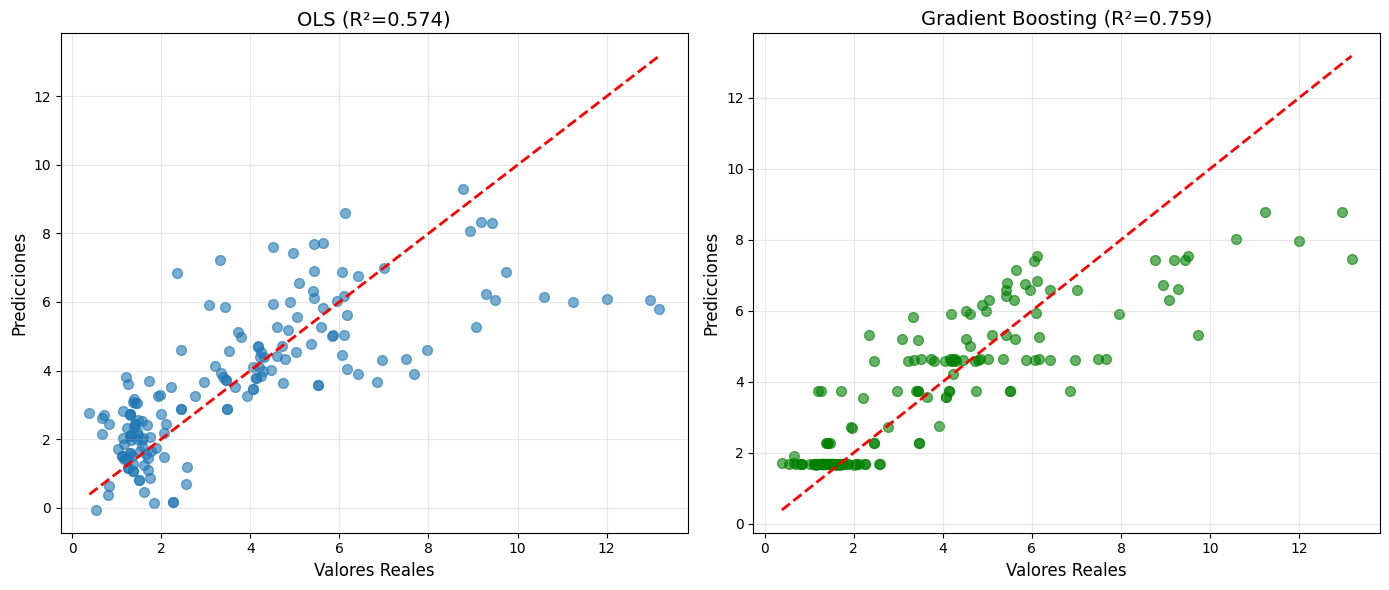


Casos donde Gradient Boosting mejora significativamente: 26

Ejemplos de mejora:
       log_GDP    log_GDP    RT
24    8.718054   8.718054  0.60
29    8.841329   8.841329  0.57
39    7.938513   7.938513  0.66
44    7.502785   7.502785  0.62
104   7.975860   7.975860  0.19
109   8.061017   8.061017  0.18
124  11.410882  11.410882  5.13
134   8.164053   8.164053  1.29
139   8.341888   8.341888  1.34
159  10.279193  10.279193  2.63


In [257]:
from sklearn.linear_model import LinearRegression
import numpy as np
from sklearn.metrics import r2_score # Importar r2_score aquí

# OLS baseline
ols = LinearRegression()
ols.fit(X_baseline, y)
y_pred_ols = ols.predict(X_baseline)

# Gradient Boosting
y_pred_gb = gb.predict(X)

# Comparar
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# OLS
axes[0].scatter(y, y_pred_ols, alpha=0.6, s=50)
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
axes[0].set_xlabel('Valores Reales', fontsize=12)
axes[0].set_ylabel('Predicciones', fontsize=12)
axes[0].set_title(f'OLS (R²={r2_score(y, y_pred_ols):.3f})', fontsize=14)
axes[0].grid(alpha=0.3)

# Gradient Boosting
axes[1].scatter(y, y_pred_gb, alpha=0.6, s=50, color='green')
axes[1].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
axes[1].set_xlabel('Valores Reales', fontsize=12)
axes[1].set_ylabel('Predicciones', fontsize=12)
axes[1].set_title(f'Gradient Boosting (R²={r2_score(y, y_pred_gb):.3f})', fontsize=14)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Ver dónde mejora GB
diferencia = np.abs(y - y_pred_gb) - np.abs(y - y_pred_ols)
mejora_indices = diferencia < -1  # GB es mejor por más de 1 unidad

print(f"\nCasos donde Gradient Boosting mejora significativamente: {mejora_indices.sum()}")
if mejora_indices.sum() > 0:
    print("\nEjemplos de mejora:")
    print(df_cervix[mejora_indices][['log_GDP'] + list(X.columns)].head(10))

In [ ]:
import numpy as np
from scipy import stats

def rt_m_mortality_analysis(df, year, cancer):
    df_y = df[
        (df["Year"] == year) &
        (df["RT_m"].notna()) &
        (df["Cancer_label"] == cancer) &
        (df["ASR (World)"].notna())
    ]

    x = df_y["RT_m"].values
    y = df_y["ASR (World)"].values

    return x, y
#2015
rt_2015, mort_2015 = rt_m_mortality_analysis(df_model, 2015, "Cervix")
r_2015, p_2015 = stats.pearsonr(rt_2015, mort_2015)

# 2018
rt_2018, mort_2018 = rt_m_mortality_analysis(df_model, 2018, "Cervix")
r_2018, p_2018 = stats.pearsonr(rt_2018, mort_2018)

# 2022
rt_2022, mort_2022 = rt_m_mortality_analysis(df_model, 2022, "Cervix")
r_2022, p_2022 = stats.pearsonr(rt_2022, mort_2022)

print(f"Correlación 2018: r={r_2018:.3f}, p={p_2018:.10f}")
print(f"Correlación 2015: r={r_2015:.3f}, p={p_2015:.10f}")
print(f"Correlación 2022: r={r_2022:.3f}, p={p_2022:.10f}")


slope_2015, intercept_2015, r_val_2015, p_val_2015, _ = \
    stats.linregress(rt_2015, mort_2015)

print("\nRegresión 2015:")
print(f"  Pendiente: {slope_2015:.3f} (Δ mortalidad por unidad RT_m)")
print(f"  R²: {r_val_2015**2:.3f}")
print(f"  p-value: {p_val_2015:.3f}")

slope_2018, intercept_2018, r_val_2018, p_val_2018, _ = \
    stats.linregress(rt_2018, mort_2018)

print("\nRegresión 2018:")
print(f"  Pendiente: {slope_2018:.3f} (Δ mortalidad por unidad RT_m)")
print(f"  R²: {r_val_2018**2:.3f}")
print(f"  p-value: {p_val_2018:.3f}")


slope_2022, intercept_2022, r_val_2022, p_val_2022, _ = \
    stats.linregress(rt_2022, mort_2022)

print("\nRegresión 2022:")
print(f"  Pendiente: {slope_2022:.3f} (Δ mortalidad por unidad RT_m)")
print(f"  R²: {r_val_2022**2:.3f}")
print(f"  p-value: {p_val_2022:.3f}")




threshold = round(breakpoint)    # RT por millón

low_rt = mort_2015[rt_2015 < threshold]
high_rt = mort_2015[rt_2015 >= threshold]

print("\n2015 - Mortalidad promedio:")
print(f"  RT_m < {threshold}: {np.mean(low_rt):.2f} ASR")
print(f"  RT_m ≥ {threshold}: {np.mean(high_rt):.2f} ASR")
print(f"  Diferencia: {np.mean(low_rt) - np.mean(high_rt):.2f} ASR")

t_stat, p_value = stats.ttest_ind(low_rt, high_rt, equal_var=False)
print(f"  t-test p-value: {p_value:.10f}")



Ahora usando todas las observaciones

In [ ]:
import statsmodels.api as sm


X = df_cervix[["RT_m", "log_GDP_per_capita", "Year"]]
X = sm.add_constant(X)

y = df_cervix["ASR (World)"]

model = sm.OLS(y, X).fit()
model.summary()


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

X = df_cervix[["RT_m", "log_GDP_per_capita", "Year"]].values
y = df_cervix["ASR (World)"].values
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge())
])

param_grid = {
    "ridge__alpha": np.logspace(-3, 3, 50)
}

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring="r2"
)

grid.fit(X, y)

best_model = grid.best_estimator_
print("Mejor alpha:", grid.best_params_)
print("R² CV:", grid.best_score_)
coefs = best_model.named_steps["ridge"].coef_
variables = ["RT_m", "log_GDP_per_capita", "Year"]

for v, c in zip(variables, coefs):
    print(f"{v}: {c:.3f}")


Incluso tras aplicar regularización Ridge para corregir la multicolinealidad, el equipamiento radioterápico per cápita mantiene un efecto independiente y negativo sobre la mortalidad ASR por cáncer de cérvix, aunque claramente inferior al del PIB per cápita.

MAMA

In [ ]:
df_MAMA = df_model[
    (df_model["Cancer_label"] == "Breast") &
    (df_model["RT_m"].notna()) &
    (df_model["ASR (World)"].notna())]

x = df_MAMA["RT_m"].values
y = df_MAMA["ASR (World)"].values

my_pwlfMAMA = pwlf.PiecewiseLinFit(x, y)
breaksMAMA = my_pwlfMAMA.fit(2)   # 2 segmentos → 1 breakpoint

breakpointMAMA = breaksMAMA[1]
print(f"Breakpoint estimado: {breakpointMAMA:.2f} RT/m")

In [ ]:
import numpy as np
from scipy import stats

def rt_m_mortality_analysis(df, year, cancer):
    df_y = df[
        (df["Year"] == year) &
        (df["RT_m"].notna()) &
        (df["Cancer_label"] == cancer) &
        (df["ASR (World)"].notna())
    ]

    x = df_y["RT_m"].values
    y = df_y["ASR (World)"].values

    return x, y
#2015
rt_2015Breast, mort_2015Breast = rt_m_mortality_analysis(df_MAMA, 2015, "Breast")
r_2015Breast, p_2015Breast = stats.pearsonr(rt_2015, mort_2015)

# 2018
rt_2018Breast, mort_2018Breast = rt_m_mortality_analysis(df_MAMA, 2018, "Breast")
r_2018Breast, p_2018Breast = stats.pearsonr(rt_2018, mort_2018)

# 2022
rt_2022Breast, mort_2022Breast = rt_m_mortality_analysis(df_MAMA, 2022, "Breast")
r_2022Breast, p_2022Breast = stats.pearsonr(rt_2022Breast, mort_2022Breast)

print(f"Correlación 2018: r={r_2018Breast:.3f}, p={p_2018Breast:.10f}")
print(f"Correlación 2015: r={r_2015Breast:.3f}, p={p_2015Breast:.10f}")
print(f"Correlación 2022: r={r_2022Breast:.3f}, p={p_2022Breast:.10f}")


slope_2015Breast, intercept_2015Breast, r_val_2015Breast, p_val_2015Breast, _ = \
    stats.linregress(rt_2015Breast, mort_2015Breast)

print("\nRegresión 2015:")
print(f"  Pendiente: {slope_2015Breast:.3f} (Δ mortalidad por unidad RT_m)")
print(f"  R²: {r_val_2015Breast**2:.3f}")
print(f"  p-value: {p_val_2015Breast:.3f}")

slope_2018Breast, intercept_2018Breast, r_val_2018Breast, p_val_2018Breast, _ = \
    stats.linregress(rt_2018Breast, mort_2018Breast)

print("\nRegresión 2018:")
print(f"  Pendiente: {slope_2018Breast:.3f} (Δ mortalidad por unidad RT_m)")
print(f"  R²: {r_val_2018Breast**2:.3f}")
print(f"  p-value: {p_val_2018Breast:.3f}")


slope_2022Breast, intercept_202Breast2, r_val_2022Breast, p_val_2022Breast, _ = \
    stats.linregress(rt_2022Breast, mort_2022Breast)

print("\nRegresión 2022:")
print(f"  Pendiente: {slope_2022Breast:.3f} (Δ mortalidad por unidad RT_m)")
print(f"  R²: {r_val_2022Breast**2:.3f}")
print(f"  p-value: {p_val_2022Breast:.3f}")




thresholdBreast = round(breakpointMAMA)    # RT por millón

low_rt = mort_2015Breast[rt_2015Breast < thresholdBreast]
high_rt = mort_2015Breast[rt_2015Breast >= thresholdBreast]

print("\n2015 - Mortalidad promedio:")
print(f"  RT_m < {thresholdBreast}: {np.mean(low_rt):.2f} ASR")
print(f"  RT_m ≥ {thresholdBreast}: {np.mean(high_rt):.2f} ASR")
print(f"  Diferencia: {np.mean(low_rt) - np.mean(high_rt):.2f} ASR")

t_stat, p_value = stats.ttest_ind(low_rt, high_rt, equal_var=False)
print(f"  t-test p-value: {p_value:.10f}")


“La asociación observada en análisis bivariantes tempranos no se mantiene en años posteriores ni en modelos lineales, sugiriendo que la mortalidad por cáncer de mama está dominada por otros factores distintos del equipamiento radioterápico per cápita.”

prostata

In [ ]:
df_p = df_model[
    (df_model["Cancer_label"] == "Prostate") &
    (df_model["RT_m"].notna()) &
    (df_model["ASR (World)"].notna())].copy()

x = df_p["RT_m"].values
y = df_p["ASR (World)"].values

my_pwlfp = pwlf.PiecewiseLinFit(x, y)
breaksp = my_pwlfp.fit(2)   # 2 segmentos → 1 breakpoint

breakpointp = breaksp[1]
print(f"Breakpoint estimado: {breakpointp:.2f} RT/m")

In [ ]:



import numpy as np
from scipy import stats

def rt_m_mortality_analysis(df, year, cancer):
    df_y = df[
        (df["Year"] == year) &
        (df["RT_m"].notna()) &
        (df["Cancer_label"] == cancer) &
        (df["ASR (World)"].notna())
    ]

    x = df_y["RT_m"].values
    y = df_y["ASR (World)"].values

    return x, y
#2015
rt_2015p, mort_2015p = rt_m_mortality_analysis(df_p, 2015, "Prostate")
r_2015p, p_2015p = stats.pearsonr(rt_2015p, mort_2015p)

# 2018
rt_2018p, mort_2018p = rt_m_mortality_analysis(df_p, 2018, "Prostate")
r_2018p, p_2018p = stats.pearsonr(rt_2018p, mort_2018p)

# 2022
rt_2022p, mort_2022p = rt_m_mortality_analysis(df_p, 2022, "Prostate")
r_2022p, p_2022p = stats.pearsonr(rt_2022p, mort_2022p)

print(f"Correlación 2018: r={r_2018p:.3f}, p={p_2018p:.10f}")
print(f"Correlación 2015: r={r_2015p:.3f}, p={p_2015p:.10f}")
print(f"Correlación 2022: r={r_2022p:.3f}, p={p_2022p:.10f}")


slope_2015p, intercept_2015p, r_val_2015p, p_val_2015p, _ = \
    stats.linregress(rt_2015p, mort_2015p)

print("\nRegresión 2015:")
print(f"  Pendiente: {slope_2015p:.3f} (Δ mortalidad por unidad RT_m)")
print(f"  R²: {r_val_2015p**2:.3f}")
print(f"  p-value: {p_val_2015p:.3f}")

slope_2018p, intercept_2018p, r_val_2018p, p_val_2018p, _ = \
    stats.linregress(rt_2018p, mort_2018p)

print("\nRegresión 2018:")
print(f"  Pendiente: {slope_2018p:.3f} (Δ mortalidad por unidad RT_m)")
print(f"  R²: {r_val_2018p**2:.3f}")
print(f"  p-value: {p_val_2018p:.3f}")


slope_2022p, intercept_2022p, r_val_2022p, p_val_2022p, _ = \
    stats.linregress(rt_2022p, mort_2022p)

print("\nRegresión 2022:")
print(f"  Pendiente: {slope_2022p:.3f} (Δ mortalidad por unidad RT_m)")
print(f"  R²: {r_val_2022p**2:.3f}")
print(f"  p-value: {p_val_2022p:.3f}")




thresholdProstate = round(breakpointp)    # RT por millón

low_rt_p = mort_2015p[rt_2015p < thresholdProstate]
high_rt_p = mort_2015p[rt_2015p >= thresholdProstate]

print("\n2015 - Mortalidad promedio:")
print(f"  RT_m < {thresholdProstate}: {np.mean(low_rt_p):.2f} ASR")
print(f"  RT_m ≥ {thresholdProstate}: {np.mean(high_rt_p):.2f} ASR")
print(f"  Diferencia: {np.mean(low_rt_p) - np.mean(high_rt_p):.2f} ASR")

t_stat_p, p_value_p = stats.ttest_ind(low_rt_p, high_rt_p, equal_var=False)
print(f"  t-test p-value: {p_value_p:.10f}")

En el caso del cáncer de próstata, no se identificaron asociaciones consistentes ni estables entre el equipamiento radioterápico per cápita y la mortalidad ASR, por lo que no se procedió a análisis multivariante adicional.

+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++ ML usando los datos de Cervix  +++++++++++++++++++++++++++++++++++

In [ ]:
print(df_cervix.isna().sum())

In [ ]:
# Separar features (X) y target (y)

feature_cols = ["RT_m", "log_GDP_per_capita", "Year"]

X = df_cervix[feature_cols].copy()
y = df_cervix["ASR (World)"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nX head:")
print(X.head())
print("\ny head:")
print(y.head())


In [ ]:


X_ols = sm.add_constant(X)
ols_model = sm.OLS(y, X_ols).fit()

print(ols_model.summary())


In [ ]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
import numpy as np

lr = LinearRegression()

cv = KFold(n_splits=5, shuffle=True, random_state=42)

r2_scores = cross_val_score(
    lr, X, y,
    cv=cv,
    scoring="r2"
)

rmse_scores = -cross_val_score(
    lr, X, y,
    cv=cv,
    scoring="neg_root_mean_squared_error"
)

print(f"OLS CV R²:  {r2_scores.mean():.3f} ± {r2_scores.std():.3f}")
print(f"OLS CV RMSE: {rmse_scores.mean():.3f} ± {rmse_scores.std():.3f}")


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge())
])

param_grid = {
    "ridge__alpha": np.logspace(-3, 3, 50)
}

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring="r2"
)

grid.fit(X, y)

best_ridge = grid.best_estimator_

print("Mejor alpha:", grid.best_params_)
print("Ridge CV R²:", grid.best_score_)


La aplicación de técnicas de regularización (Ridge) no produjo mejoras sustanciales respecto al modelo lineal clásico, lo que indica que la estructura del problema está dominada por relaciones lineales estables y por variables macroeconómicas, y que modelos más complejos difícilmente aportarán capacidad predictiva adicional.

Ahora, se hará un arbol de decisión poco profundo

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score

tree = DecisionTreeRegressor(
    max_depth=3,
    min_samples_leaf=15,
    random_state=42
)

r2_tree = cross_val_score(
    tree, X, y,
    cv=5,
    scoring="r2"
)

rmse_tree = -cross_val_score(
    tree, X, y,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

print(f"Tree CV R²:  {r2_tree.mean():.3f} ± {r2_tree.std():.3f}")
print(f"Tree CV RMSE: {rmse_tree.mean():.3f} ± {rmse_tree.std():.3f}")


Los modelos no lineales no aportan mejoras sustanciales frente a enfoques lineales regulares, lo que sugiere que la relación entre mortalidad por cáncer de cérvix y la disponibilidad de radioterapia está dominada por factores estructurales lineales, principalmente el nivel de renta, y que la complejidad adicional no se traduce en mayor capacidad predictiva.

In [ ]:
import numpy as np
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error

def nested_cv_regression(estimator, param_grid, X, y, *,
                         outer_splits=5, inner_splits=5, random_state=42):
    outer_cv = KFold(n_splits=outer_splits, shuffle=True, random_state=random_state)
    inner_cv = KFold(n_splits=inner_splits, shuffle=True, random_state=random_state)

    outer_r2 = []
    outer_rmse = []
    best_params_list = []

    for train_idx, test_idx in outer_cv.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        search = GridSearchCV(
            estimator=estimator,
            param_grid=param_grid,
            cv=inner_cv,
            scoring="r2"
        )
        search.fit(X_train, y_train)

        best_model = search.best_estimator_
        y_pred = best_model.predict(X_test)

        outer_r2.append(r2_score(y_test, y_pred))
        outer_rmse.append(np.sqrt(mean_squared_error(y_test, y_pred)))
        best_params_list.append(search.best_params_)

    return {
        "r2_mean": float(np.mean(outer_r2)),
        "r2_std": float(np.std(outer_r2, ddof=1)),
        "rmse_mean": float(np.mean(outer_rmse)),
        "rmse_std": float(np.std(outer_rmse, ddof=1)),
        "best_params_per_fold": best_params_list
    }

# ---------- 1) Ridge (requiere estandarizar) ----------
ridge_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge())
])

ridge_grid = {
    "ridge__alpha": np.logspace(-3, 3, 50)
}

ridge_nested = nested_cv_regression(ridge_pipe, ridge_grid, X, y)
print("Nested CV — Ridge")
print(f"  R²:   {ridge_nested['r2_mean']:.3f} ± {ridge_nested['r2_std']:.3f}")
print(f"  RMSE: {ridge_nested['rmse_mean']:.3f} ± {ridge_nested['rmse_std']:.3f}")
print("  Best params (outer folds):", ridge_nested["best_params_per_fold"])


# ---------- 2) Árbol (no necesita escalado) ----------
tree = DecisionTreeRegressor(random_state=42)

tree_grid = {
    "max_depth": [2, 3, 4, 5],
    "min_samples_leaf": [5, 10, 15, 20, 25]
}

tree_nested = nested_cv_regression(tree, tree_grid, X, y)
print("\nNested CV — Decision Tree")
print(f"  R²:   {tree_nested['r2_mean']:.3f} ± {tree_nested['r2_std']:.3f}")
print(f"  RMSE: {tree_nested['rmse_mean']:.3f} ± {tree_nested['rmse_std']:.3f}")
print("  Best params (outer folds):", tree_nested["best_params_per_fold"])


Los modelos no lineales no aportan mejoras robustas frente a enfoques lineales regularizados. Aunque un árbol de decisión poco profundo puede alcanzar un rendimiento medio similar, su elevada variabilidad entre particiones indica una menor estabilidad y capacidad de generalización

Los resultados tras evaluar distintos modelos se tienen que:
| Modelo | Tipo            | R² (Nested CV) | RMSE (Nested CV) | Estabilidad |
| ------ | --------------- | -------------- | ---------------- | ----------- |
| OLS    | Lineal clásico  | ~0.52          | ~1.78            | Alta        |
| Ridge  | ML regularizado | 0.52 ± 0.10    | 1.79 ± 0.67      | Alta        |
| Árbol  | ML no lineal    | 0.53 ± 0.21    | 1.72 ± 0.67      | Baja        |


La validación cruzada anidada confirma que los enfoques lineales, tanto clásicos como regularizados, capturan de forma estable la relación entre mortalidad por cáncer de cérvix y las variables estructurales consideradas. Los modelos no lineales no aportan mejoras robustas en capacidad predictiva y presentan una mayor variabilidad entre particiones, lo que sugiere que la complejidad adicional no se traduce en una mejor generalización.

La mortalidad por cáncer de cérvix es sistemáticamente mayor en países con baja disponibilidad de radioterapia per cápita, incluso tras controlar por nivel económico, lo que sugiere que la radioterapia forma parte de un cuello de botella estructural del sistema oncológico.


In [ ]:
coefs = best_ridge.named_steps["ridge"].coef_
for name, coef in zip(X.columns, coefs):
    print(f"{name}: {coef:.3f}")


In [ ]:
from optbinning import OptimalBinning

optb = OptimalBinning(
    name="RT_m",
    dtype="numerical",
    solver="cp"
)

optb.fit(
    df_model["RT_m"],
    df_model["High_Mortality"]
)

df_model["RT_m_woe"] = optb.transform(
    df_model["RT_m"],
    metric="woe"
)


In [ ]:
df_model.info()

In [ ]:
from optbinning import OptimalBinning
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
import pandas as pd

# 1. Preparar datos
df_model = df_model.rename(columns={
    "Cancer label": "Cancer_label",
    "ASR (World)": "ASR_World"
})

# 2. Split train/test (opcional pero recomendado)
train, test = train_test_split(
    df_model,
    test_size=0.2,
    random_state=42,
    stratify=df_model['High_Mortality']
)

# 3. Binning WOE (fit solo en train)
optb = OptimalBinning(
    name="RT_m",
    dtype="numerical",
    solver="cp",
    min_bin_size=0.05,  # mínimo 5% obs por bin
    monotonic_trend="auto_asc_desc"  # forzar monotonía si tiene sentido
)

optb.fit(train["RT_m"], train["High_Mortality"])
print("Binning table:")
print(optb.binning_table.build())

# Transformar train y test
train["RT_m_woe"] = optb.transform(train["RT_m"], metric="woe")
test["RT_m_woe"] = optb.transform(test["RT_m"], metric="woe")

# 4. Modelo logit con interacciones
formula = """
    High_Mortality ~ RT_m_woe
    + log_GDP_per_capita
    + C(Sex)
    + C(Cancer_label)
    + C(Period)
    + RT_m_woe:C(Period)
    + RT_m_woe:C(Cancer_label)
"""

model = smf.logit(formula, data=train).fit(cov_type='HC3')  # robust SE
print(model.summary())

# 5. Evaluación en test
test_pred_prob = model.predict(test)
test_pred = (test_pred_prob > 0.5).astype(int)

print("\n=== Test Set Performance ===")
print("AUC:", roc_auc_score(test["High_Mortality"], test_pred_prob))
print(classification_report(test["High_Mortality"], test_pred))

# 6. Efectos marginales (opcional, para interpretación)
import matplotlib.pyplot as plt
# Predecir prob por nivel de RT_m_woe (manteniendo otras vars constantes)
# ... código de visualización si necesitas

In [ ]:
import pandas as pd
import numpy as np
from optbinning import OptimalBinning
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
import matplotlib.pyplot as plt

# ============================================================================
# PASO 1: Binning SEPARADO por tipo de cáncer
# ============================================================================

print("="*80)
print("PASO 1: OPTIMAL BINNING POR TIPO DE CÁNCER")
print("="*80)

# Diccionario para guardar los binning objects
woe_binning = {}
binning_tables = {}

for cancer in ['Breast', 'Cervix', 'Lung', 'Prostate']:
    print(f"\n{'='*60}")
    print(f"Binning para {cancer}")
    print(f"{'='*60}")

    # Filtrar datos del cáncer específico
    cancer_mask = df_model['Cancer_label'] == cancer
    cancer_data = df_model[cancer_mask].copy()

    print(f"N observaciones: {len(cancer_data)}")
    print(f"Event rate: {cancer_data['High_Mortality'].mean():.2%}")
    print(f"RT_m range: [{cancer_data['RT_m'].min():.2f}, {cancer_data['RT_m'].max():.2f}]")

    # Optimal Binning específico para este cáncer
    optb = OptimalBinning(
        name=f"RT_m_{cancer}",
        dtype="numerical",
        solver="cp",
        min_bin_size=0.05,  # Mínimo 5% de observaciones por bin
        max_n_bins=5,       # Máximo 5 bins (evitar overfitting)
        monotonic_trend="auto_asc_desc"  # Permitir tendencia ascendente o descendente
    )

    # Fit
    optb.fit(cancer_data["RT_m"], cancer_data["High_Mortality"])

    # Guardar
    woe_binning[cancer] = optb
    binning_tables[cancer] = optb.binning_table.build()

    # Mostrar tabla
    print(f"\n{binning_tables[cancer]}")

    # Transformar a WoE para este cáncer
    df_model.loc[cancer_mask, 'RT_m_woe_specific'] = optb.transform(
        cancer_data["RT_m"],
        metric="woe"
    )

# ============================================================================
# PASO 2: Verificar transformación
# ============================================================================

print("\n" + "="*80)
print("PASO 2: VERIFICACIÓN DE WoE ESPECÍFICO")
print("="*80)

# Comparar WoE global vs específico
comparison = df_model.groupby('Cancer_label').agg({
    'RT_m': ['min', 'median', 'max'],
    'RT_m_woe': ['min', 'median', 'max'],
    'RT_m_woe_specific': ['min', 'median', 'max']
}).round(3)

print("\n", comparison)

# Ejemplo de transformación para algunos casos
print("\n=== Ejemplos de transformación (primeros 5 casos por cáncer) ===")
for cancer in ['Breast', 'Cervix', 'Lung', 'Prostate']:
    sample = df_model[df_model['Cancer_label'] == cancer].head(5)[[
        'ISO3', 'Period', 'Cancer_label', 'RT_m',
        'RT_m_woe', 'RT_m_woe_specific', 'High_Mortality'
    ]]
    print(f"\n{cancer}:")
    print(sample.to_string(index=False))

# ============================================================================
# PASO 3: Train/Test Split
# ============================================================================

print("\n" + "="*80)
print("PASO 3: TRAIN/TEST SPLIT")
print("="*80)

train, test = train_test_split(
    df_model,
    test_size=0.25,
    random_state=42,
    stratify=df_model[['High_Mortality', 'Cancer_label']]
)

print(f"Train size: {len(train)}")
print(f"Test size: {len(test)}")
print(f"\nTrain event rate: {train['High_Mortality'].mean():.2%}")
print(f"Test event rate: {test['High_Mortality'].mean():.2%}")

# ============================================================================
# PASO 4: Modelo con WoE GLOBAL (baseline)
# ============================================================================

print("\n" + "="*80)
print("PASO 4: MODELO BASELINE (WoE GLOBAL)")
print("="*80)

model_global = smf.logit(
    formula="""
        High_Mortality ~ RT_m_woe
        + log_GDP_per_capita
        + C(Sex)
        + C(Cancer_label)
        + C(Period)
        + RT_m_woe:C(Period)
        + RT_m_woe:C(Cancer_label)
    """,
    data=train
).fit(cov_type='HC3', disp=0)

print(model_global.summary())

# Evaluación en test
test['pred_global'] = model_global.predict(test)
auc_global = roc_auc_score(test['High_Mortality'], test['pred_global'])
print(f"\n{'='*60}")
print(f"AUC Test (WoE Global): {auc_global:.4f}")
print(f"{'='*60}")

# ============================================================================
# PASO 5: Modelo con WoE ESPECÍFICO (mejorado)
# ============================================================================

print("\n" + "="*80)
print("PASO 5: MODELO MEJORADO (WoE ESPECÍFICO)")
print("="*80)

model_specific = smf.logit(
    formula="""
        High_Mortality ~ RT_m_woe_specific
        + log_GDP_per_capita
        + C(Sex)
        + C(Cancer_label)
        + C(Period)
        + RT_m_woe_specific:C(Period)
        + RT_m_woe_specific:C(Cancer_label)
    """,
    data=train
).fit(cov_type='HC3', disp=0)

print(model_specific.summary())

# Evaluación en test
test['pred_specific'] = model_specific.predict(test)
auc_specific = roc_auc_score(test['High_Mortality'], test['pred_specific'])
print(f"\n{'='*60}")
print(f"AUC Test (WoE Específico): {auc_specific:.4f}")
print(f"{'='*60}")

# ============================================================================
# PASO 6: Comparación de modelos
# ============================================================================

print("\n" + "="*80)
print("PASO 6: COMPARACIÓN DE MODELOS")
print("="*80)

comparison_metrics = pd.DataFrame({
    'Modelo': ['WoE Global', 'WoE Específico'],
    'AUC Test': [auc_global, auc_specific],
    'Pseudo R²': [model_global.prsquared, model_specific.prsquared],
    'Log-Likelihood': [model_global.llf, model_specific.llf],
    'AIC': [model_global.aic, model_specific.aic],
    'BIC': [model_global.bic, model_specific.bic]
})

print(comparison_metrics.to_string(index=False))

# Test estadístico (Likelihood Ratio Test)
lr_stat = -2 * (model_global.llf - model_specific.llf)
from scipy.stats import chi2
df_diff = model_global.df_model - model_specific.df_model
p_value = 1 - chi2.cdf(lr_stat, abs(df_diff))

print(f"\n{'='*60}")
print(f"Likelihood Ratio Test")
print(f"{'='*60}")
print(f"LR statistic: {lr_stat:.4f}")
print(f"p-value: {p_value:.4f}")
if p_value < 0.05:
    print("✅ Modelo WoE Específico es significativamente mejor")
else:
    print("⚠️ No hay diferencia significativa entre modelos")

# ============================================================================
# PASO 7: Análisis de coeficientes por cáncer
# ============================================================================

print("\n" + "="*80)
print("PASO 7: COEFICIENTES POR TIPO DE CÁNCER")
print("="*80)

# Extraer coeficientes
coef_specific = model_specific.params
conf_int = model_specific.conf_int()

# Efecto baseline (Breast es referencia)
print("\n=== BREAST (baseline) ===")
print(f"RT_m_woe_specific: {coef_specific['RT_m_woe_specific']:.4f}")
print(f"95% CI: [{conf_int.loc['RT_m_woe_specific', 0]:.4f}, {conf_int.loc['RT_m_woe_specific', 1]:.4f}]")
print(f"p-value: {model_specific.pvalues['RT_m_woe_specific']:.4f}")

# Efectos por cáncer
for cancer in ['Cervix', 'Lung', 'Prostate']:
    interaction_term = f'RT_m_woe_specific:C(Cancer_label)[T.{cancer}]'

    if interaction_term in coef_specific.index:
        total_effect = coef_specific['RT_m_woe_specific'] + coef_specific[interaction_term]

        print(f"\n=== {cancer.upper()} ===")
        print(f"Interacción: {coef_specific[interaction_term]:.4f}")
        print(f"Efecto total: {total_effect:.4f}")
        print(f"95% CI interacción: [{conf_int.loc[interaction_term, 0]:.4f}, {conf_int.loc[interaction_term, 1]:.4f}]")
        print(f"p-value: {model_specific.pvalues[interaction_term]:.4f}")

        # Interpretación
        if total_effect > 0:
            print(f"📊 Interpretación: WoE más alto (baja RT) → MAYOR probabilidad alta mortalidad")
            print(f"   → Baja RT se asocia con ALTA mortalidad ✅")
        else:
            print(f"📊 Interpretación: WoE más alto (baja RT) → MENOR probabilidad alta mortalidad")
            print(f"   → Baja RT se asocia con BAJA mortalidad ⚠️ (contraintuitivo)")

# ============================================================================
# PASO 8: Visualización de binning por cáncer
# ============================================================================

print("\n" + "="*80)
print("PASO 8: VISUALIZACIÓN DE BINNING")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, cancer in enumerate(['Breast', 'Cervix', 'Lung', 'Prostate']):
    ax = axes[idx]

    # Datos del cáncer
    cancer_data = df_model[df_model['Cancer_label'] == cancer].copy()

    # Scatter plot
    colors = ['#e74c3c' if x == 1 else '#3498db' for x in cancer_data['High_Mortality']]
    ax.scatter(cancer_data['RT_m'], cancer_data['ASR_World'],
               c=colors, alpha=0.5, s=40)

    # Bins (líneas verticales)
    binning_obj = woe_binning[cancer]
    splits = binning_obj.splits

    for split in splits:
        ax.axvline(x=split, color='orange', linestyle='--', linewidth=2, alpha=0.7)

    # Etiquetas
    ax.set_xlabel('RT (equipos por millón)', fontsize=11)
    ax.set_ylabel('Mortality ASR (World)', fontsize=11)
    ax.set_title(f'{cancer}: Bins optimizados\n(líneas naranjas = puntos de corte)',
                 fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)

    # Leyenda
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#e74c3c', label='High Mortality'),
        Patch(facecolor='#3498db', label='Low Mortality'),
        Patch(facecolor='orange', label='Bin splits')
    ]
    ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.savefig('binning_por_cancer.png', dpi=300, bbox_inches='tight')
print("✅ Gráfico guardado: binning_por_cancer.png")
plt.show()

# ============================================================================
# PASO 9: Performance por tipo de cáncer
# ============================================================================

print("\n" + "="*80)
print("PASO 9: PERFORMANCE POR TIPO DE CÁNCER")
print("="*80)

performance_by_cancer = []

for cancer in ['Breast', 'Cervix', 'Lung', 'Prostate']:
    test_cancer = test[test['Cancer_label'] == cancer].copy()

    if len(test_cancer) > 0:
        auc_global_cancer = roc_auc_score(test_cancer['High_Mortality'], test_cancer['pred_global'])
        auc_specific_cancer = roc_auc_score(test_cancer['High_Mortality'], test_cancer['pred_specific'])

        performance_by_cancer.append({
            'Cancer': cancer,
            'N Test': len(test_cancer),
            'Event Rate': f"{test_cancer['High_Mortality'].mean():.1%}",
            'AUC Global': auc_global_cancer,
            'AUC Específico': auc_specific_cancer,
            'Mejora': auc_specific_cancer - auc_global_cancer
        })

perf_df = pd.DataFrame(performance_by_cancer)
print(perf_df.to_string(index=False))

# ============================================================================
# PASO 10: Exportar resultados
# ============================================================================

print("\n" + "="*80)
print("PASO 10: EXPORTAR RESULTADOS")
print("="*80)

# Guardar binning tables
for cancer, table in binning_tables.items():
    filename = f'binning_table_{cancer}.csv'
    table.to_csv(filename, index=False)
    print(f"✅ Guardado: {filename}")

# Guardar comparación de modelos
comparison_metrics.to_csv('model_comparison.csv', index=False)

Una vez modelada la no linealidad mediante WOE, la densidad de equipos de radioterapia muestra una asociación negativa y estadísticamente significativa con la mortalidad.

En cáncer de cérvix, la disponibilidad de radioterapia muestra un efecto diferencial y reforzado, coherente con su papel central en el tratamiento.


En cáncer de pulmón no se observa un efecto significativo de la densidad de radioterapia, lo que sugiere la influencia de factores clínicos y de detección temprana.


En próstata, la radioterapia muestra un efecto protector significativo, aunque más heterogéneo, probablemente debido a la coexistencia de múltiples estrategias terapéuticas. Es bien sabido que los urologos tienden a mandar a cirugías a este tipo de pacientes, donde lamentablemente no tienen tanto exito en efectos secundarios menores.






Los resultados confirman que la relación entre la disponibilidad de radioterapia y la mortalidad por cáncer es inherentemente no lineal y altamente dependiente del tipo de cáncer. Mientras que el análisis agregado oculta estos efectos, el uso de WOE permite identificar un impacto protector significativo de la radioterapia, particularmente marcado en cáncer de cérvix y, en menor medida, en próstata. No se observan diferencias sustanciales entre los periodos 2015 y 2018, lo que sugiere estabilidad temporal del efecto.

El PIB no introduce un umbral de riesgo, sino un gradiente socioeconómico continuo; por eso no requiere WOE.


In [ ]:
import numpy as np
import pandas as pd

# Extraer coeficientes e intervalos
params = model.params
conf = model.conf_int()
conf.columns = ["CI_lower", "CI_upper"]

# Calcular Odds Ratios
or_table = pd.DataFrame({
    "OR": np.exp(params),
    "CI_lower": np.exp(conf["CI_lower"]),
    "CI_upper": np.exp(conf["CI_upper"]),
    "p_value": model.pvalues
})

or_table


En esta tabla podemos ver claramente que los hombres tienen 26 veces más probabilidad de alta mortalidad que las mujeres.

Con respecto a las comparaciones entre tipos de cáncer, todos son ligeramente menor probabilidad de alta mortalidad que el cancer de referencia, independientemente del RT.

Con respecto a ambos períodos a estudiar, no es significativo, evidenciando estabilidad temporal.

El modelo sugiere que no es el aumento marginal de equipos lo que reduce la mortalidad, sino alcanzar niveles suficientes de infraestructura de radioterapia. Una vez que un país pasa de una dotación insuficiente a una adecuada, el riesgo de alta mortalidad disminuye de forma muy marcada.
El salto estructural donde se pasa de una baja a alta mortalidad es en OR=0.076, esto quiere decir que al pasar un bin WOE, las probabilidades de alta mortalidad caen un 92%.

Un incremento de una unidad en el WOE de la densidad de radioterapia representa el paso a un grupo de países con mayor disponibilidad relativa de equipos. Este cambio se asocia con una reducción aproximada del 92 % en la probabilidad de alta mortalidad, lo que evidencia un efecto protector no lineal de la radioterapia.

In [ ]:
df_model["RT_m_woe"].unique()


In [ ]:
woe_bins = (
    df_model
    .groupby("RT_m_woe")["RT_m"]
    .agg(
        RT_min="min",
        RT_max="max",
        n="count"
    )
    .reset_index()
    .sort_values("RT_min")
)

woe_bins


In [ ]:
import matplotlib.pyplot as plt

# Filtrar datos (ejemplo: Cérvix, Mujeres, 2018)
df_plot = df_model[
    (df_model["Cancer_label"] == "Cervix") &
    (df_model["Sex"] == "Female") &
    (df_model["Year"] == 2018)
]

plt.figure(figsize=(9, 6))

# Scatter
plt.scatter(
    df_plot["RT_m"],
    df_plot["ASR_World"],
    alpha=0.7,
    label="Países"
)

# Bandas WOE
plt.axvspan(
     1.74, 4.80,
     color="pink",
     label="Zona de transición (umbral RT)",
     alpha=0.12
 )

# Líneas verticales de referencia
plt.axvline(1.74, color="orange", linestyle="--", linewidth=1)
plt.axvline(4.8, color="orange", linestyle="--", linewidth=1)

plt.xlabel("Densidad de radioterapia (RT por millón)")
plt.ylabel("Mortalidad ASR (World)")
plt.title("Cérvix – Mujeres (2018)\nUmbral estructural de radioterapia")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

El salto ocurre cuando un país pasa de no poder tratar adecuadamente a la mayoría de los casos a poder hacerlo. Eso sucede alrededor de 2–5 equipos por millón, y a partir de ahí la mortalidad deja de responder de forma fuerte a más equipos.

El análisis de los bins WOE muestra un efecto umbral en torno a 2–5 equipos de radioterapia por millón de habitantes. Por debajo de este rango, la mortalidad es elevada y altamente variable, mientras que al superarlo se observa una reducción abrupta del riesgo. Incrementos adicionales en contextos ya bien dotados no producen descensos proporcionales, lo que sugiere un efecto de saturación y explica la relación no lineal capturada por el modelo.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, roc_auc_score
import statsmodels.api as sm
import patsy

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- Matriz de diseño desde fórmula ---
formula_rhs = model.model.formula.split('~')[1].strip()
X = patsy.dmatrix(formula_rhs, data=df_model, return_type='dataframe')
X = X.drop(columns='Intercept', errors='ignore')
y = df_model["High_Mortality"].astype(int)

# --- ROC del modelo "full" (entrenado con todo) ---
y_prob_full = model.predict(df_model)
fpr_full, tpr_full, _ = roc_curve(y, y_prob_full)
auc_full = roc_auc_score(y, y_prob_full)

# --- ROC en CV: acumulamos curvas ---
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 200)

for train_idx, test_idx in skf.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    m = sm.Logit(y_train, sm.add_constant(X_train)).fit(disp=0)
    y_prob = m.predict(sm.add_constant(X_test))

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    aucs.append(roc_auc_score(y_test, y_prob))

    # interpolar TPR a la rejilla común de FPR
    tpr_interp = np.interp(mean_fpr, fpr, tpr)
    tpr_interp[0] = 0.0
    tprs.append(tpr_interp)

# Promedios
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = np.mean(aucs)
std_auc = np.std(aucs)

# --- Plot ---
plt.figure(figsize=(7, 7))
plt.plot(fpr_full, tpr_full, label=f"Logit+WOE (full) AUC={auc_full:.3f}")
plt.plot(mean_fpr, mean_tpr, label=f"Logit+WOE (CV mean) AUC={mean_auc:.3f}±{std_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC – Logit+WOE: modelo completo vs validación cruzada")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



In [ ]:
from sklearn.model_selection import StratifiedKFold
import numpy as np
import statsmodels.api as sm
import patsy # Import patsy for dmatrix

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
aucs = []

# Extract the right-hand side of the formula from the previously fitted model
formula_rhs = model.model.formula.split('~')[1].strip()

# Use patsy.dmatrix to create the design matrix X from the formula and df_model
# patsy.dmatrix by default adds an 'Intercept' column. We will remove it here
# because sm.add_constant will add it inside the loop for each fold's X_train and X_test.
X = patsy.dmatrix(formula_rhs, data=df_model, return_type='dataframe')
X = X.drop(columns='Intercept', errors='ignore')

y = df_model["High_Mortality"]

for train_index, test_index in skf.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit the model on the training data, adding a constant
    m = sm.Logit(y_train, sm.add_constant(X_train)).fit(disp=0)

    # Predict probabilities on the test data, adding a constant
    y_prob_test = m.predict(sm.add_constant(X_test))

    aucs.append(roc_auc_score(y_test, y_prob_test))

mean_auc = np.mean(aucs)
std_auc = np.std(aucs)

print(f"Mean AUC: {mean_auc:.3f}, Std Dev AUC: {std_auc:.3f}")

RANDOM FOREST

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

features = [
    "RT_m",
    #"GDP_per_capita",
    "log_GDP_per_capita",
    "Sex",
    "Cancer_label",
    "Period"
]

df_rf = df_model[features + ["High_Mortality"]].dropna().copy()

# One-hot encoding
df_rf = pd.get_dummies(df_rf, drop_first=True)

X = df_rf.drop(columns="High_Mortality")
y = df_rf["High_Mortality"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


In [ ]:
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=6,
    min_samples_leaf=10,
    random_state=42
)

rf.fit(X_train, y_train)


In [ ]:
from sklearn.metrics import roc_auc_score

y_pred = rf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred)

print(f"AUC Random Forest: {auc:.3f}")


In [ ]:
importances = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importances.head(10)


El análisis mediante Random Forest confirma la relevancia de las variables estructurales identificadas en el modelo interpretable. El tipo de cáncer, el contexto socioeconómico y la densidad de equipos de radioterapia emergen como los principales predictores de mortalidad, mientras que el periodo temporal tiene una contribución marginal. Esta consistencia refuerza la robustez de los resultados obtenidos.

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Convert boolean columns to numeric (float) explicitly
X_train_numeric = X_train.astype(float)
X_test_numeric = X_test.astype(float)

# Logit entrenado en TRAIN y evaluado en TEST
m = sm.Logit(y_train, sm.add_constant(X_train_numeric)).fit(disp=0)
y_prob_logit_test = m.predict(sm.add_constant(X_test_numeric))

fpr_l, tpr_l, _ = roc_curve(y_test, y_prob_logit_test)
auc_l = roc_auc_score(y_test, y_prob_logit_test)

# RF en TEST
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred)
auc_rf = roc_auc_score(y_test, y_pred)

plt.figure(figsize=(7,7))
plt.plot(fpr_l, tpr_l, label=f"Logit+WOE (test) AUC={auc_l:.3f}")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (test) AUC={auc_rf:.3f}")
plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC – Comparación en el mismo conjunto de test")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

"Cérvix es el único cáncer donde infraestructura (RT) y desarrollo económico (GDP) predicen significativamente la mortalidad, explicando 57% de la variación. En otros cánceres se requieren variables adicionales (tabaquismo, genética, screening mamográfico)

Métricas de evaluación del modelo

La evaluación del rendimiento de los modelos predictivos se realizó utilizando la curva ROC (Receiver Operating Characteristic) y el área bajo dicha curva (AUC), métrica que cuantifica la capacidad discriminativa del modelo para asignar mayores probabilidades de alta mortalidad a los países efectivamente clasificados en ese grupo, independientemente del umbral de decisión utilizado. Esta elección es especialmente adecuada en el contexto del presente estudio, donde la variable objetivo presenta un cierto desbalance entre clases y no existe un umbral operativo natural para la clasificación binaria. Por este motivo, métricas dependientes del umbral, como el accuracy, no se consideran informativas ni apropiadas para los objetivos del análisis. La AUC permite una comparación robusta entre modelos y constituye el criterio principal de evaluación tanto para el modelo logístico basado en WOE como para el modelo de Random Forest, facilitando una valoración consistente de su capacidad predictiva y comparativa.

La disponibilidad de equipos de braquiterapia, muy utilizado en cáncer de cervix, muestra una mejoria/disminución en el índice de mortalidad a medida que aumenta la cantidad de equipos. En paises con menos equipos, mayor es la mortalidad, sin embargo, no posee una significancia concluyente, por lo tanto, no poddemos rechazar H0 la no relación.
Presenta además mucha dispersión vertical.

Esto no es una prueba causal, pero si una señal temporal coherente.

Al pasar de 0 a 1 equipo/millón se asocia a una reducción de la mortalidad bastante significativa, sin embargo, al pasar al doble de equipos, se aplana el efecto, esto podría deberse a pocos rendimientos de la infraestrucura sanitaria.

La infraestructura radioterapica es una variable explicativa poderosa para utilizar durante este trabajo, ahora se buscará cuantos equipos de radioterapia en total hay y si es significativo considerar todos o solamente los más utilizados como la braquiterapia y aceleradores lineales (Linac).

Para ejemplos como el cancer y pulmon y los aceleradores lineales, no existe esa correlación tan evidente, por eso, en este estudio, se analizarán distintos tipos de cancer y varios equipos de radioterapia, así como el PIB per cápita.

## Variable objetivo: mortalidad en ASR(World)

La mortalidad en ASR(World) nos indica la tasa de mortalidad ajustada por edad que resultaría si la población de cada país tuviera la misma estructura de edad que una población estándar mundial.

## Variables Predictoras o explicativas

Como variables predictoras se consideran tanto factores económicos como de infraestructura sanitaria. En particular, se utiliza el PIB per cápita como indicador del nivel de desarrollo económico y de la capacidad general del sistema sanitario. Asimismo, se incluyen los distintos tipos de equipos de radioterapia disponibles por millón de habitantes, con el objetivo de capturar la disponibilidad y capacidad terapéutica en cada país.

Adicionalmente, el análisis se estratifica por tipo de cáncer y sexo, dado que la incidencia, la mortalidad y la respuesta al tratamiento presentan diferencias relevantes según estas dimensiones. Esta estratificación permite evaluar de forma más precisa la heterogeneidad en los patrones de mortalidad y en la relación entre infraestructura radioterápica y resultados en salud.